# 1. BasketGraph 3.0 — Enterprise GNN Product Recommendation

### Retail recommendation portfolio | Instacart basket completion | Polars + PyTorch Geometric

This notebook rebuilds the attached `Graph-NN` recommendation notebook into a **leakage-aware, full-catalog, enterprise-style benchmark**.

**Business question.** Given the products already visible in a grocery basket, which products are most plausible additions?

**Modeling contract.** Complete orders are split first into train/validation/test. The product graph and all learned popularity/co-occurrence statistics are then fitted on training data only. Validation determines checkpoint selection and the optional ensemble weight; test is opened once at the end.

**Primary metric:** NDCG@10  
**Supporting metrics:** Precision@K, Recall@K, HitRate@K, MRR@K, Coverage@K, Novelty@K, and target recallability.

**Models compared**
1. Popularity
2. Item-kNN co-occurrence
3. Basket Matrix Factorization (TruncatedSVD)
4. Weighted LightGCN-style item graph model with metadata-aware node initialization
5. Validation-tuned Graph + kNN hybrid

The notebook intentionally uses **static Matplotlib/Seaborn visuals only**. No Plotly/Bokeh/interactive graph libraries are used.

## 3. Reproducible experiment contract

The data pipeline follows Polars' lazy CSV scan pattern so projections and filters can be pushed toward the scan, and streaming collection can process large tables in batches. This is the recommended direction for large CSV workloads in current Polars documentation.

References:
- Polars lazy scans: https://docs.pola.rs/api/python/stable/reference/api/polars.scan_csv.html
- Polars streaming: https://docs.pola.rs/user-guide/concepts/streaming/
- PyTorch Geometric installation: https://pytorch-geometric.readthedocs.io/en/stable/notes/installation.html
- LightGCN / `LGConv`: https://pytorch-geometric.readthedocs.io/en/2.3.0/generated/torch_geometric.nn.conv.LGConv.html
- LightGCN paper: https://arxiv.org/abs/2002.02126
- SR-GNN: https://ojs.aaai.org/index.php/AAAI/article/view/3804

In [1]:
# -------------------------------------------------------------------
# 0. Kaggle setup — only install what is missing.
# -------------------------------------------------------------------
import importlib.util
import subprocess
import sys

def ensure_package(module_name: str, pip_name: str) -> None:
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_package("polars", "polars")
ensure_package("torch_geometric", "torch-geometric")

print("Dependency check complete.")

Installing torch-geometric ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00
Dependency check complete.


In [2]:
from __future__ import annotations

import copy
import gc
import math
import os
import random
import time
from collections import defaultdict
from dataclasses import dataclass, asdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
from scipy import sparse
from scipy.sparse.linalg import norm as sparse_norm

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import LGConv
from torch_geometric.utils import coalesce

from IPython.display import display, Markdown

# Static-only visualization contract.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})

@dataclass(frozen=True)
class Config:
    seed: int = 42

    # Data
    max_orders: int | None = 180_000
    min_basket_size: int = 3
    max_basket_size: int = 60
    val_fraction: float = 0.10
    test_fraction: float = 0.10

    # Training graph
    max_graph_baskets: int = 100_000
    max_graph_items_per_basket: int = 24
    graph_neighbors: int = 32
    ppmi_clip_quantile: float = 0.995

    # Evaluation
    mask_fraction: float = 0.25
    val_eval_baskets: int = 2_500
    test_eval_baskets: int = 4_000
    ks: tuple[int, ...] = (5, 10, 20)

    # GNN
    embedding_dim: int = 48
    gnn_layers: int = 1
    epochs: int = 100
    train_baskets_per_epoch: int = 12_000
    batch_size: int = 1024
    negatives_per_positive: int = 8
    hard_negative_share: float = 0.50
    popular_negative_share: float = 0.25
    learning_rate: float = 0.0001
    weight_decay: float = 1e-5
    grad_clip: float = 5.0
    eval_every: int = 1
    patience: int = 5

    # Baselines / uncertainty
    mf_components: int = 48
    knn_topk: int = 200
    bootstrap_samples: int = 200

    # Static graph/embedding visuals
    graph_plot_nodes: int = 140
    graph_plot_edges: int = 500
    embedding_plot_nodes: int = 800

cfg = Config()

def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Polars: {pl.__version__}")
display(pd.Series(asdict(cfg), name="value").to_frame().style.set_caption("Experiment configuration"))

Device: cuda
PyTorch: 2.10.0+cu128
Polars: 1.35.2


,value
seed,42
max_orders,180000
min_basket_size,3
max_basket_size,60
val_fraction,0.100000
test_fraction,0.100000
max_graph_baskets,100000
max_graph_items_per_basket,24
graph_neighbors,32
ppmi_clip_quantile,0.995000


In [3]:
# Fast diagnostic dashboard: run after the data split and again after training when variables exist.
def diagnostic_dashboard():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    parts = [p for p in ("train", "val", "test") if p in baskets]
    for p in parts:
        sizes = np.asarray([len(x) for x in baskets[p]])
        axes[0, 0].hist(sizes, bins=20, alpha=.35, label=p)
    axes[0, 0].set(title="Basket-size distribution", xlabel="Items", ylabel="Count")
    axes[0, 0].legend(frameon=False)
    if 'item_basket_support' in globals():
        support = np.sort(item_basket_support)[::-1]
        axes[0, 1].plot(np.arange(1, len(support)+1), support)
        axes[0, 1].set(xscale="log", yscale="log", title="Catalog support long tail", xlabel="Rank", ylabel="Support")
    if 'history_df' in globals() and len(history_df):
        axes[1, 0].plot(history_df["epoch"], history_df["loss"], marker="o")
        axes[1, 0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")
    if 'validation_results' in globals() and len(validation_results):
        validation_results.plot.barh(x="model", y="NDCG@10", ax=axes[1, 1], legend=False)
        axes[1, 1].set(title="Validation NDCG@10", xlabel="NDCG@10")
    plt.tight_layout(); plt.show()

# Lightweight integrity checks catch common silent errors before expensive evaluation.
def run_integrity_checks():
    assert n_items == len(catalog_names) == len(item_basket_support)
    assert edge_index.shape[0] == 2 and edge_index.shape[1] == edge_weight.numel()
    assert all(len(c) > 0 and len(t) > 0 and set(c).isdisjoint(set(t)) for c,t in val_examples + test_examples)
    print(f"Integrity checks passed | items={n_items:,} | edges={edge_index.shape[1]:,}")


## 4. Data discovery and high-performance Polars pipeline

The transaction table is intentionally kept as a `LazyFrame` as long as possible. We select only the fields needed to build baskets and frequencies; product names and department labels are joined later, after the transaction table has been compressed to product-level metadata.

This avoids a common portfolio anti-pattern: materializing millions of transaction rows just to attach a few small dimension-table columns.

In [4]:
FILES = {
    "orders": "orders.csv",
    "prior": "order_products__prior.csv",
    "products": "products.csv",
    "aisles": "aisles.csv",
    "departments": "departments.csv",
}

def resolve_paths(root: str = "/kaggle/input") -> dict[str, Path]:
    root_path = Path(root)
    if not root_path.exists():
        raise FileNotFoundError(
            f"{root} is not mounted. On Kaggle, attach the Instacart Online Grocery Shopping dataset."
        )
    out: dict[str, Path] = {}
    for key, name in FILES.items():
        matches = list(root_path.rglob(name))
        if not matches:
            raise FileNotFoundError(f"Missing required file: {name}")
        out[key] = matches[0]
    return out

PATHS = resolve_paths()
display(pd.DataFrame({"table": list(PATHS), "path": [str(v) for v in PATHS.values()]}))

orders_lf = (
    pl.scan_csv(PATHS["orders"])
    .select(
        pl.col("order_id").cast(pl.Int32),
        pl.col("user_id").cast(pl.Int32),
        pl.col("order_number").cast(pl.Int16),
        pl.col("eval_set").cast(pl.String),
        pl.col("order_dow").cast(pl.Int8),
        pl.col("order_hour_of_day").cast(pl.Int8),
    )
    .filter(pl.col("eval_set") == "prior")
)

prior_lf = (
    pl.scan_csv(PATHS["prior"])
    .select(
        pl.col("order_id").cast(pl.Int32),
        pl.col("product_id").cast(pl.Int32),
        pl.col("add_to_cart_order").cast(pl.Int16),
        pl.col("reordered").cast(pl.Int8),
    )
)

products_meta = (
    pl.read_csv(PATHS["products"])
    .select(
        pl.col("product_id").cast(pl.Int32),
        pl.col("product_name").cast(pl.String),
        pl.col("aisle_id").cast(pl.Int16),
        pl.col("department_id").cast(pl.Int8),
    )
    .join(
        pl.read_csv(PATHS["aisles"]).select(
            pl.col("aisle_id").cast(pl.Int16),
            pl.col("aisle").cast(pl.String),
        ),
        on="aisle_id",
        how="left",
    )
    .join(
        pl.read_csv(PATHS["departments"]).select(
            pl.col("department_id").cast(pl.Int8),
            pl.col("department").cast(pl.String),
        ),
        on="department_id",
        how="left",
    )
)

print("Lazy transaction scans created; dimension tables materialized because they are small.")

,table,path
0,orders,/kaggle/input/datasets/yasserh/instacart-onlin...
1,prior,/kaggle/input/datasets/yasserh/instacart-onlin...
2,products,/kaggle/input/datasets/yasserh/instacart-onlin...
3,aisles,/kaggle/input/datasets/yasserh/instacart-onlin...
4,departments,/kaggle/input/datasets/yasserh/instacart-onlin...


Lazy transaction scans created; dimension tables materialized because they are small.


## 5. Order-level split and target-recallability accounting

Orders are the split unit. This prevents a product from the same order leaking across partitions.

A production recommender would normally add a chronological, user-level split. For this anonymous basket-completion benchmark, the order-level split keeps the task well defined while making the limitation explicit.

In [5]:
eligible = (
    prior_lf
    .group_by("order_id")
    .agg(pl.len().cast(pl.Int16).alias("raw_size"))
    .filter(
        pl.col("raw_size").is_between(
            cfg.min_basket_size,
            cfg.max_basket_size,
            closed="both",
        )
    )
    .join(orders_lf, on="order_id", how="inner")
    .collect(engine="streaming")
)

rng = np.random.default_rng(cfg.seed)

if cfg.max_orders is not None and eligible.height > cfg.max_orders:
    take_idx = rng.choice(
        eligible.height,
        cfg.max_orders,
        replace=False,
    )

    eligible = (
        eligible
        .with_row_index("__row_idx")
        .filter(pl.col("__row_idx").is_in(take_idx.tolist()))
        .drop("__row_idx")
    )

perm = rng.permutation(eligible.height)
n_test = int(eligible.height * cfg.test_fraction)
n_val = int(eligible.height * cfg.val_fraction)

split = np.full(eligible.height, "train", dtype="<U5")
split[perm[:n_test]] = "test"
split[perm[n_test:n_test + n_val]] = "val"

selected_orders = eligible.with_columns(
    pl.Series("split", split)
)

assert selected_orders["order_id"].n_unique() == selected_orders.height

split_counts = (
    selected_orders
    .group_by("split")
    .agg(pl.len().alias("orders"))
    .sort("split")
)

display(
    split_counts.to_pandas()
    .style.format({"orders": "{:,.0f}"})
    .set_caption("Order-level partitions")
)

,split,orders
0,test,"18,000"
1,train,"144,000"
2,val,"18,000"


## 6. Training-only catalog and compact basket representation

The recommender can only rank products whose representations are learned from training data. Instead of silently deleting non-training products from validation/test, we explicitly track them.

This produces two separate concepts:
- **candidate catalog:** products known from training
- **recallable target:** a hidden target that exists in that candidate catalog

The test report therefore includes target recallability, which is operationally meaningful for a production system.

In [6]:
keys = selected_orders.select("order_id", "split")

selected_lf = prior_lf.join(
    keys.lazy(),
    on="order_id",
    how="inner",
)

train_freq = (
    selected_lf
    .filter(pl.col("split") == "train")
    .group_by("product_id")
    .agg(pl.len().cast(pl.Int32).alias("train_purchase_events"))
    .sort("train_purchase_events", descending=True)
    .collect(engine="streaming")
)

raw_catalog_ids = train_freq["product_id"].to_numpy()

# Optional scaling guardrail. The default uses every training-observed product.
if raw_catalog_ids.size == 0:
    raise ValueError("No training-observed products were found.")

product2idx = {int(pid): i for i, pid in enumerate(raw_catalog_ids)}
n_items = len(raw_catalog_ids)

# Compact transaction table: no product-name join on the large fact table.
compact_events = (
    selected_lf
    .select("order_id", "product_id", "add_to_cart_order", "reordered", "split")
    .collect(engine="streaming")
)

# Keep only candidate-catalog products for modelable context/targets, but preserve
# the raw event count so cold-start removal is measurable.
candidate_event_mask = compact_events["product_id"].is_in(raw_catalog_ids)
candidate_events = compact_events.filter(candidate_event_mask)

basket_frame = (
    candidate_events
    .sort(["order_id", "add_to_cart_order"])
    .group_by(["order_id", "split"], maintain_order=True)
    .agg(
        pl.col("product_id").alias("products"),
        pl.col("reordered").mean().alias("reorder_share"),
        pl.len().alias("candidate_item_count"),
    )
    .filter(pl.col("candidate_item_count") >= cfg.min_basket_size)
)

baskets: dict[str, list[np.ndarray]] = {}
for part in ("train", "val", "test"):
    product_lists = basket_frame.filter(pl.col("split") == part)["products"].to_list()
    baskets[part] = [
        np.asarray([product2idx[int(pid)] for pid in xs], dtype=np.int32)
        for xs in product_lists
    ]

catalog = (
    pl.DataFrame({
        "product_id": raw_catalog_ids,
        "product_idx": np.arange(n_items, dtype=np.int32),
    })
    .join(products_meta, on="product_id", how="left")
    .join(train_freq, on="product_id", how="left")
    .sort("product_idx")
)

catalog_names = np.asarray(catalog["product_name"].fill_null("Unknown product").to_list(), dtype=object)

# Training basket frequency: distinct basket support.
item_basket_support = np.zeros(n_items, dtype=np.int64)
for basket in baskets["train"]:
    np.add.at(item_basket_support, np.unique(basket), 1)

raw_event_counts = compact_events.group_by("split").agg(pl.len().alias("events"))
candidate_event_counts = candidate_events.group_by("split").agg(pl.len().alias("candidate_events"))
event_recallability = (
    raw_event_counts
    .join(candidate_event_counts, on="split", how="left")
    .with_columns(
        (pl.col("candidate_events") / pl.col("events")).alias("candidate_event_rate")
    )
)

summary = pd.DataFrame({
    "split": list(baskets.keys()),
    "baskets": [len(baskets[s]) for s in baskets],
    "candidate_items": [sum(map(len, baskets[s])) for s in baskets],
    "mean_candidate_basket_size": [np.mean([len(b) for b in baskets[s]]) for s in baskets],
})

display(summary.style.format({
    "baskets": "{:,.0f}",
    "candidate_items": "{:,.0f}",
    "mean_candidate_basket_size": "{:.2f}",
}).set_caption(f"Training-retained candidate catalog: {n_items:,} products"))

display(
    event_recallability.to_pandas()
    .style.format({"candidate_event_rate": "{:.2%}"})
    .set_caption("Event-level candidate recallability (after training-only catalog restriction)")
)

del compact_events, candidate_events, basket_frame
gc.collect()

,split,baskets,candidate_items,mean_candidate_basket_size
0,train,"144,000","1,599,456",11.11
1,val,"17,984","199,920",11.12
2,test,"17,979","198,949",11.07


,split,events,candidate_events,candidate_event_rate
0,train,1599456,1599456,100.00%
1,val,200903,199952,99.53%
2,test,199942,198987,99.52%


68

## 7. Data diagnostics: long tail, concentration, and basket difficulty

Before fitting any model, measure the shape of the recommendation problem. A model that looks good only because the catalog is dominated by a few staples is not demonstrating strong contextual ranking.

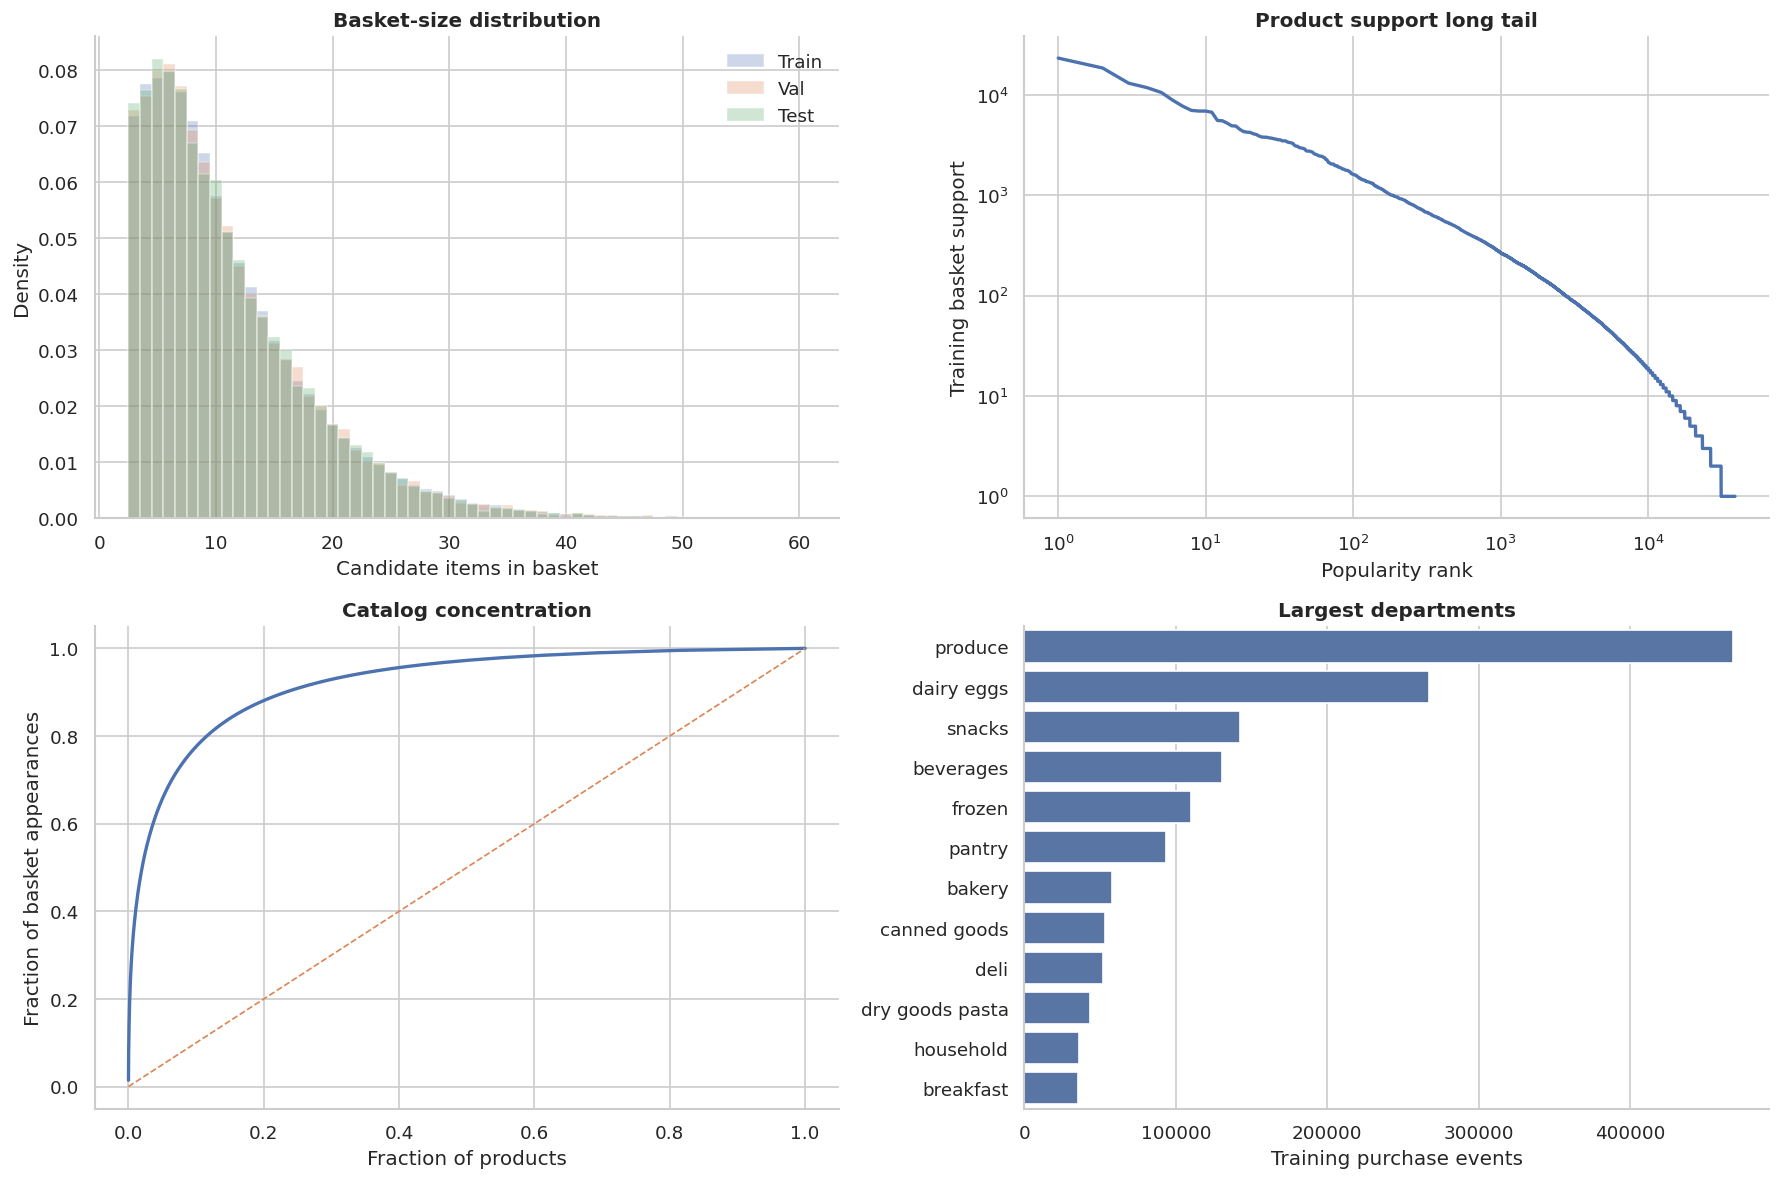

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for part in ("train", "val", "test"):
    sizes = np.asarray([len(x) for x in baskets[part]])
    axes[0, 0].hist(
        sizes,
        bins=np.arange(cfg.min_basket_size, cfg.max_basket_size + 2) - 0.5,
        density=True,
        alpha=0.28,
        label=part.title(),
    )

axes[0, 0].set(
    title="Basket-size distribution",
    xlabel="Candidate items in basket",
    ylabel="Density",
)
axes[0, 0].legend(frameon=False)

ranked = np.sort(item_basket_support)[::-1]
axes[0, 1].plot(
    np.arange(1, len(ranked) + 1),
    ranked,
    linewidth=2,
)
axes[0, 1].set(
    xscale="log",
    yscale="log",
    title="Product support long tail",
    xlabel="Popularity rank",
    ylabel="Training basket support",
)

share = np.cumsum(ranked) / max(ranked.sum(), 1)
axes[1, 0].plot(
    np.arange(1, len(share) + 1) / len(share),
    share,
    linewidth=2,
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[1, 0].set(
    title="Catalog concentration",
    xlabel="Fraction of products",
    ylabel="Fraction of basket appearances",
)

dept = (
    catalog
    .group_by("department")
    .agg(pl.col("train_purchase_events").sum().alias("events"))
    .sort("events", descending=True)
    .head(12)
    .to_pandas()
)
sns.barplot(
    data=dept,
    x="events",
    y="department",
    ax=axes[1, 1],
)
axes[1, 1].set(title="Largest departments", xlabel="Training purchase events", ylabel="")

plt.show()

## 8. Training product-affinity graph

### Graph design

Each node is a training-observed product. An undirected edge connects products that co-occur in a training basket.

The edge signal is **positive PMI (PPMI)**:
\[
PPMI(i,j)=\max\left(0,\log

rac{p(i,j)}{p(i)p(j)}
ight).
\]

Three engineering changes matter:

1. Pair counts and node supports are computed from the **same sampled graph basket population**.
2. Association weights are clipped/log-compressed so a small-support pair cannot dominate the graph solely through a very large PMI.
3. Symmetric normalization is computed once as \(D^{-1/2}WD^{-1/2}\). The PyG `LGConv` layer is then used with `normalize=False`, avoiding an opaque second normalization step.

In [8]:
def select_graph_baskets(
    baskets: list[np.ndarray],
    item_support: np.ndarray,
    max_baskets: int,
    max_items_per_basket: int,
    seed: int,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    ids = np.arange(len(baskets))
    if len(ids) > max_baskets:
        ids = rng.choice(ids, max_baskets, replace=False)

    selected = []
    for idx in ids:
        b = np.unique(baskets[idx])
        if len(b) > max_items_per_basket:
            # Sample with a mild inverse-popularity bias so rare products are not
            # systematically lost from long baskets.
            p = 1.0 / np.sqrt(item_support[b] + 1.0)
            p = p / p.sum()
            b = rng.choice(b, max_items_per_basket, replace=False, p=p)
        selected.append(np.sort(b).astype(np.int32))
    return selected


def build_weighted_ppmi_graph(
    baskets: list[np.ndarray],
    n_items: int,
    item_support: np.ndarray,
    max_baskets: int,
    max_items_per_basket: int,
    top_n: int,
    clip_quantile: float,
    seed: int,
):
    selected = select_graph_baskets(
        baskets,
        item_support,
        max_baskets=max_baskets,
        max_items_per_basket=max_items_per_basket,
        seed=seed,
    )

    n_graph_baskets = len(selected)
    row_ids = []
    col_ids = []

    for r, basket in enumerate(selected):
        row_ids.extend([r] * len(basket))
        col_ids.extend(basket.tolist())

    data = np.ones(len(row_ids), dtype=np.float32)
    X = sparse.csr_matrix(
        (data, (row_ids, col_ids)),
        shape=(n_graph_baskets, n_items),
        dtype=np.float32,
    )

    # Co-occurrence in the sampled graph population.
    C = (X.T @ X).tocsr()
    C.setdiag(0)
    C.eliminate_zeros()

    support = np.asarray(X.sum(axis=0)).ravel().astype(np.float64)

    coo = C.tocoo()
    mask = coo.row != coo.col

    src = coo.row[mask].astype(np.int64)
    dst = coo.col[mask].astype(np.int64)
    counts = coo.data[mask].astype(np.float64)

    valid = (support[src] > 0) & (support[dst] > 0)
    src, dst, counts = src[valid], dst[valid], counts[valid]

    # Same-population PMI denominator.
    ppmi = np.maximum(
        0.0,
        np.log(
            (counts * n_graph_baskets)
            / (support[src] * support[dst] + 1e-12)
        ),
    )

    positive = ppmi > 0
    src, dst, ppmi, counts = (
        src[positive], dst[positive], ppmi[positive], counts[positive]
    )

    if len(ppmi) == 0:
        raise RuntimeError("No positive-PMI graph edges were generated.")

    clip_value = float(np.quantile(ppmi, clip_quantile))
    ppmi_clipped = np.minimum(ppmi, clip_value)
    raw_weight = np.log1p(ppmi_clipped).astype(np.float32)

    # Retain only the strongest positive-association neighbors per source node.
    directed = sparse.csr_matrix(
        (raw_weight, (src, dst)),
        shape=(n_items, n_items),
        dtype=np.float32,
    )
    directed.setdiag(0)
    directed.eliminate_zeros()

    keep_rows, keep_cols, keep_vals = [], [], []
    for i in range(n_items):
        start, end = directed.indptr[i], directed.indptr[i + 1]
        row_cols = directed.indices[start:end]
        row_vals = directed.data[start:end]

        if len(row_vals) > top_n:
            keep_idx = np.argpartition(row_vals, -top_n)[-top_n:]
            row_cols = row_cols[keep_idx]
            row_vals = row_vals[keep_idx]

        keep_rows.extend([i] * len(row_cols))
        keep_cols.extend(row_cols.tolist())
        keep_vals.extend(row_vals.tolist())

    # Symmetrize after top-k pruning. maximum keeps the strongest direction
    # when only one of the two directed rows retained a pair.
    W_dir = sparse.csr_matrix(
        (keep_vals, (keep_rows, keep_cols)),
        shape=(n_items, n_items),
        dtype=np.float32,
    )
    W = W_dir.maximum(W_dir.T).tocsr()
    W.setdiag(0)
    W.eliminate_zeros()

    # Symmetric graph normalization computed once and audited explicitly.
    degree = np.asarray(W.sum(axis=1)).ravel().astype(np.float64)
    inv_sqrt_degree = 1.0 / np.sqrt(np.maximum(degree, 1e-12))

    D_inv = sparse.diags(inv_sqrt_degree.astype(np.float32))
    W_norm = (D_inv @ W @ D_inv).tocoo()

    edge_index = torch.tensor(
        np.vstack([W_norm.row, W_norm.col]),
        dtype=torch.long,
    )
    edge_weight = torch.tensor(
        W_norm.data,
        dtype=torch.float32,
    )

    # Final coalesce for deterministic PyG input.
    edge_index, edge_weight = coalesce(
        edge_index,
        edge_weight,
        num_nodes=n_items,
        reduce="sum",
    )

    diagnostics = {
        "graph_baskets": n_graph_baskets,
        "nodes": n_items,
        "directed_edges": int(edge_index.shape[1]),
        "mean_degree": float(np.mean(np.bincount(edge_index[0].numpy(), minlength=n_items))),
        "median_raw_degree": float(np.median(degree)),
        "ppmi_clip_value": clip_value,
        "raw_ppmi_mean": float(np.mean(ppmi)),
    }
    return edge_index, edge_weight, diagnostics, W


t0 = time.time()

edge_index_cpu, edge_weight_cpu, graph_diag, W_sparse = build_weighted_ppmi_graph(
    baskets["train"],
    n_items=n_items,
    item_support=item_basket_support,
    max_baskets=cfg.max_graph_baskets,
    max_items_per_basket=cfg.max_graph_items_per_basket,
    top_n=cfg.graph_neighbors,
    clip_quantile=cfg.ppmi_clip_quantile,
    seed=cfg.seed,
)

edge_index = edge_index_cpu.to(device)
edge_weight = edge_weight_cpu.to(device)

graph_diag["build_seconds"] = time.time() - t0
display(pd.Series(graph_diag, name="value").to_frame().style.set_caption("Training graph diagnostics"))

,value
graph_baskets,100000.000000
nodes,38774.000000
directed_edges,1150000.000000
mean_degree,29.659050
median_raw_degree,63.598030
ppmi_clip_value,9.433484
raw_ppmi_mean,3.082656
build_seconds,4.808523


## 9. Static product graph atlas

This view uses a force-directed NetworkX layout on a high-support subgraph. Node size is training basket support; node labels are shown only for the strongest local neighborhood to preserve readability.

This is a **diagnostic structural view**, not an evaluation result.

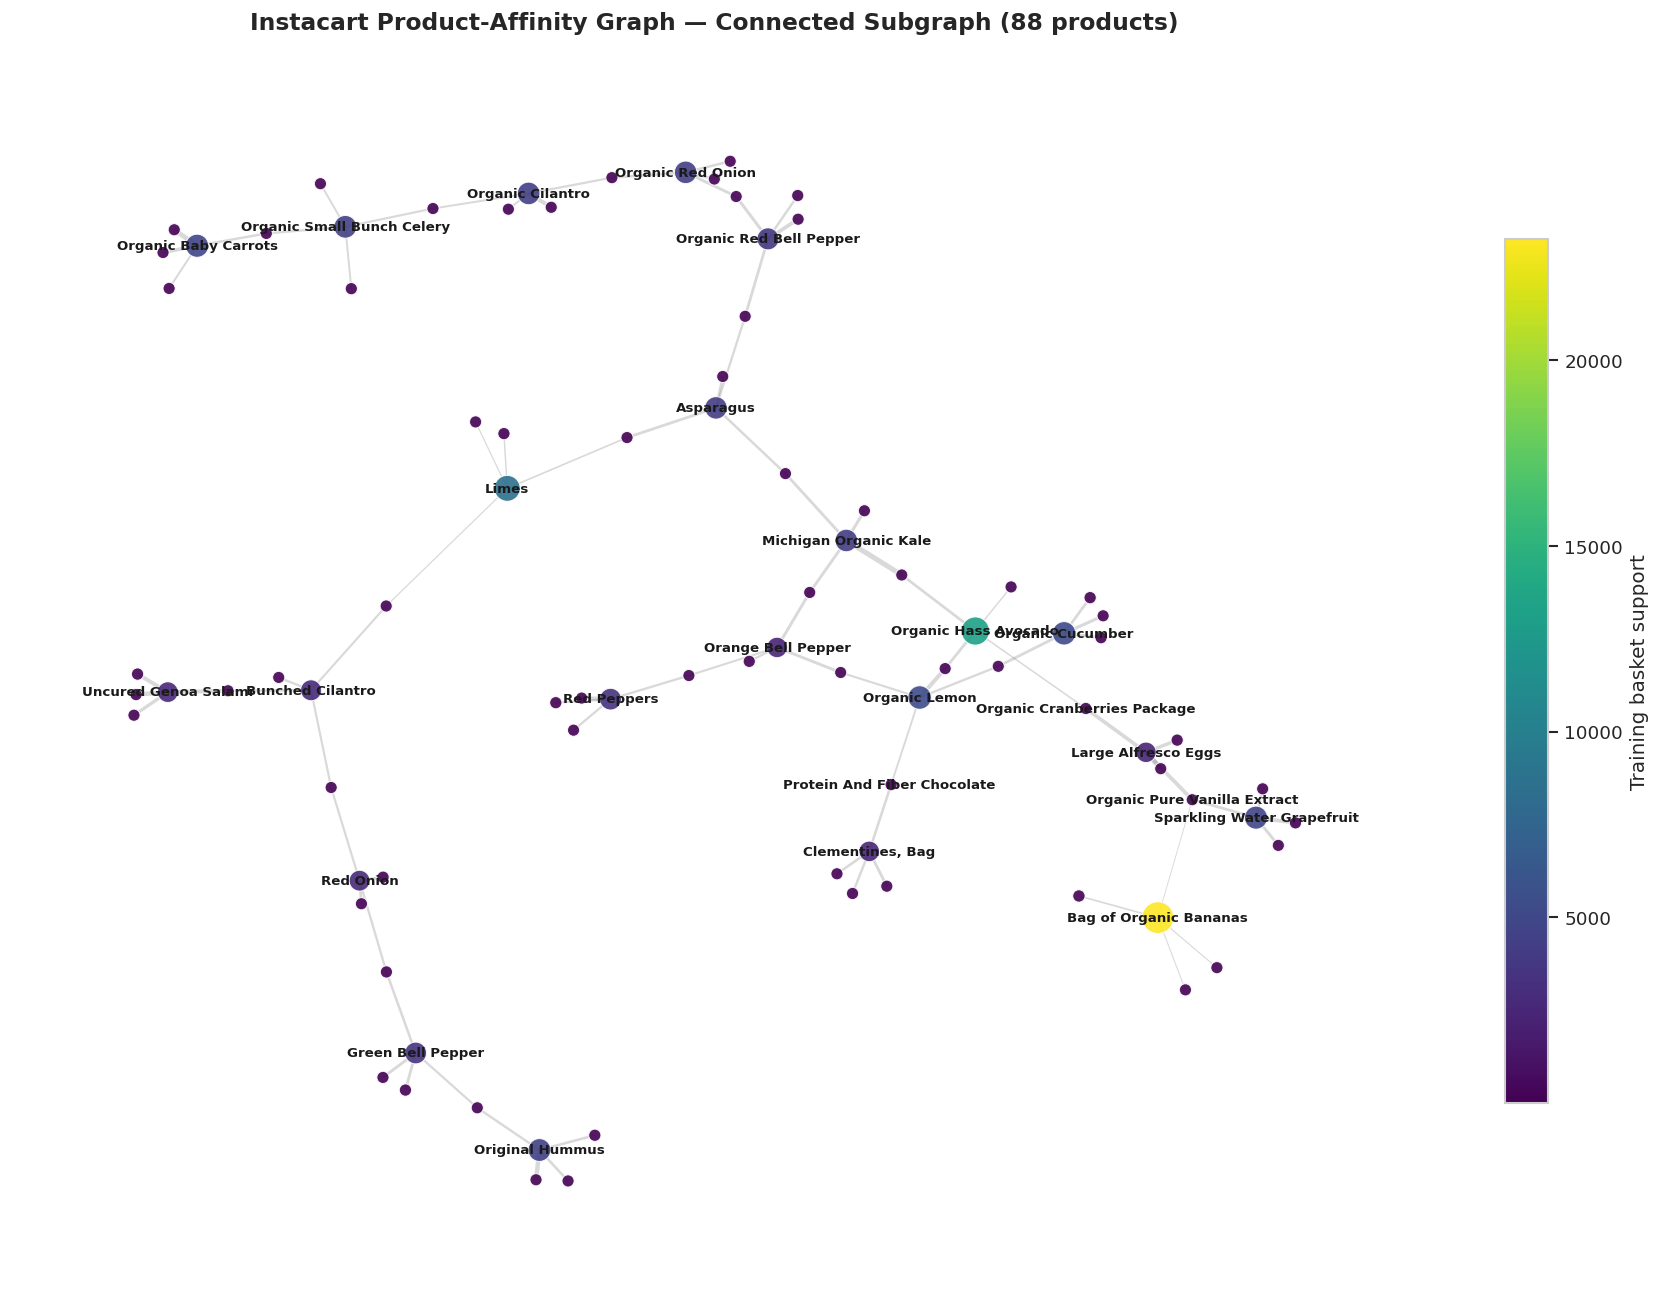

Graph generated with 88 nodes and 88 edges.


In [9]:
import math
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import torch


def plot_static_graph(
    edge_index: torch.Tensor,
    edge_weight: torch.Tensor,
    catalog_df: pl.DataFrame,
    item_support: np.ndarray,
    max_nodes: int = 100,
    top_k_neighbors: int = 4,  # Keep top K connections per node
    seed: int = 42,
    item_name_col: str = "product_name",
):
    # 1. Convert PyTorch tensors to NumPy arrays safely
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    wt = edge_weight.cpu().numpy()

    # 2. Extract item labels safely
    if item_name_col in catalog_df.columns:
        catalog_names = catalog_df[item_name_col].to_list()
    elif "product_name" in catalog_df.columns:
        catalog_names = catalog_df["product_name"].to_list()
    elif "item_name" in catalog_df.columns:
        catalog_names = catalog_df["item_name"].to_list()
    else:
        catalog_names = [f"Item_{i}" for i in range(len(item_support))]

    # 3. Select top seeds based on basket support
    top_seeds = np.argsort(item_support)[-max_nodes:]
    seed_set = set(map(int, top_seeds.tolist()))

    # Build adjacency mapping for top neighbors lookup
    adj = {}
    for a, b, w in zip(src, dst, wt):
        u, v, weight = int(a), int(b), float(w)
        if u != v:
            if u not in adj:
                adj[u] = []
            adj[u].append((v, weight))

    # 4. Top-K Neighbor Expansion: For each seed node, grab its strongest connections
    active_nodes = set(seed_set)
    edge_dict = {}

    for u in seed_set:
        if u in adj:
            # Sort neighbor candidates by edge weight descending
            sorted_neighbors = sorted(adj[u], key=lambda x: x[1], reverse=True)[
                :top_k_neighbors
            ]
            for v, w in sorted_neighbors:
                active_nodes.add(v)
                edge_key = tuple(sorted((u, v)))
                if edge_key not in edge_dict or w > edge_dict[edge_key]:
                    edge_dict[edge_key] = w

    # Build graph from active edges
    G_raw = nx.Graph()
    for (u, v), w in edge_dict.items():
        G_raw.add_edge(u, v, weight=w)

    if len(G_raw) == 0:
        print("No connected subgraph available for plotting.")
        return G_raw

    # 5. Extract Largest Connected Component to ensure clean layout structure
    largest_cc = max(nx.connected_components(G_raw), key=len)
    G = G_raw.subgraph(largest_cc).copy()

    # 6. Normalize edge weights log-scaled for smooth layout forces
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
    log_weights = np.log1p(weights)
    min_w, max_w = log_weights.min(), log_weights.max()
    
    norm_w = (
        (log_weights - min_w) / (max_w - min_w + 1e-8)
        if max_w > min_w
        else np.ones_like(log_weights)
    )

    for (u, v), nw in zip(G.edges(), norm_w):
        G[u][v]["norm_weight"] = float(nw) + 0.1

    # 7. Compute Force-Directed Layout
    pos = nx.spring_layout(
        G,
        seed=seed,
        weight="norm_weight",
        iterations=200,
        k=2.5 / math.sqrt(max(len(G), 1)),
    )

    # Compute node visual properties
    degrees = dict(G.degree())
    max_supp = item_support.max() if item_support.max() > 0 else 1
    node_sizes = [
        50 + 350 * np.sqrt((item_support[n] + 1) / (max_supp + 1))
        for n in G.nodes()
    ]

    fig, ax = plt.subplots(figsize=(15, 11))

    # 8. Render Edges & Nodes
    edge_widths = [0.3 + 2.5 * G[u][v]["norm_weight"] for u, v in G.edges()]
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        alpha=0.20,
        width=edge_widths,
        edge_color="#444444",
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=[item_support[n] for n in G.nodes()],
        cmap="viridis",
        alpha=0.90,
        linewidths=0.6,
        edgecolors="white",
    )

    # 9. Label top central nodes in this network
    label_nodes = sorted(
        G.nodes(),
        key=lambda n: (degrees[n], item_support[n]),
        reverse=True,
    )[:25]

    labels = {
        n: str(catalog_names[n])[:28]
        if n < len(catalog_names)
        else f"Item_{n}"
        for n in label_nodes
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=8,
        font_weight="bold",
    )

    ax.set_title(
        f"Instacart Product-Affinity Graph — Connected Subgraph ({len(G)} products)",
        fontsize=14,
        pad=15,
    )
    ax.axis("off")

    # 10. Add Colorbar
    sm = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=plt.Normalize(
            vmin=max(1, item_support.min()), vmax=max(1, item_support.max())
        ),
    )
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Training basket support", shrink=0.7)

    plt.tight_layout()
    plt.show()

    print(f"Graph generated with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G


# Execute the plot
graph_G = plot_static_graph(
    edge_index_cpu,
    edge_weight_cpu,
    catalog,
    item_basket_support,
    max_nodes=100,
    top_k_neighbors=4,
    seed=cfg.seed,
    item_name_col="product_name",
)

## 10. Frozen masked-basket benchmark

Every model sees the **same** validation/test questions. Training masks are regenerated each epoch as data augmentation.

A hidden target is evaluated only when:
- it belongs to the training-retained catalog, and
- the visible context is non-empty.

We keep counters for dropped/cold-start targets rather than hiding them.

,visible basket,hidden target
0,Marinara Pasta Sauce,Unsweetened Original Almond Breeze Almond Milk
1,Boneless Skinless Chicken Thighs,None
2,Cage Free Large White Eggs,None


Integrity checks passed | items=38,774 | edges=1,150,000


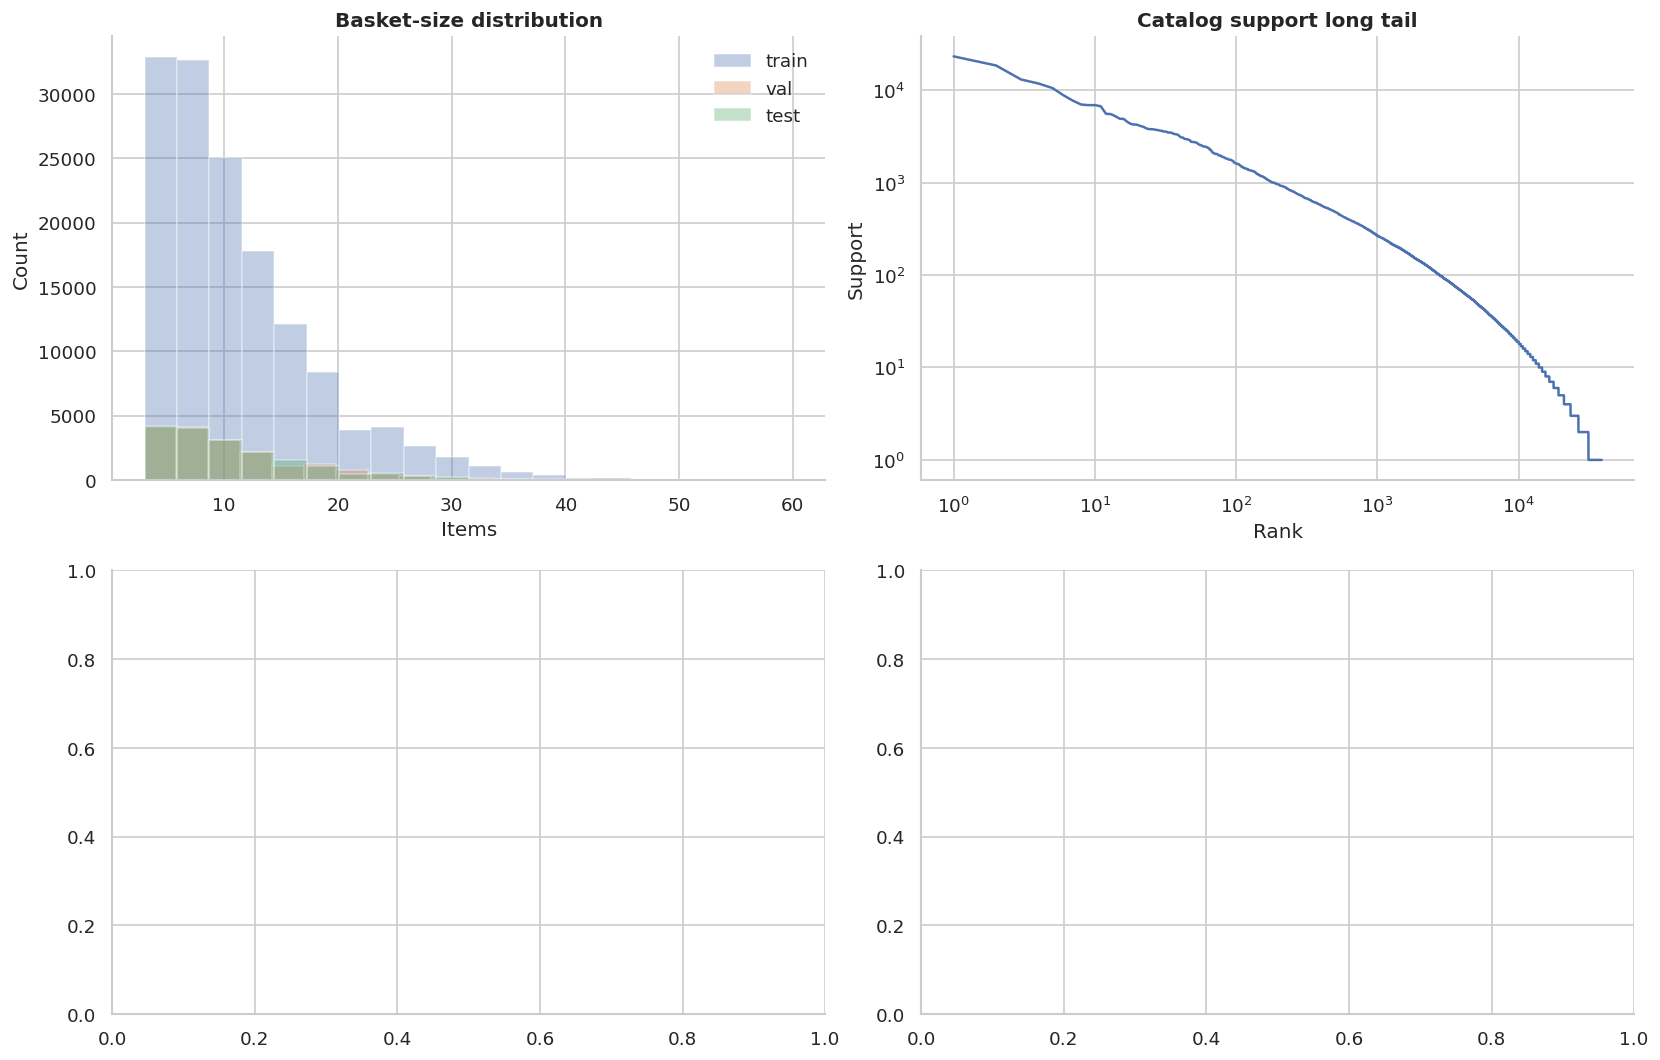

In [10]:
def mask_basket(
    basket: np.ndarray,
    fraction: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    basket = np.asarray(np.unique(basket), dtype=np.int64)
    if len(basket) < 2:
        raise ValueError("Masking requires at least two candidate items.")

    n_hide = int(round(len(basket) * fraction))
    n_hide = min(max(1, n_hide), len(basket) - 1)

    hidden_pos = rng.choice(len(basket), n_hide, replace=False)
    hidden_flag = np.zeros(len(basket), dtype=bool)
    hidden_flag[hidden_pos] = True

    context = basket[~hidden_flag]
    hidden = basket[hidden_flag]
    return context, hidden


def make_frozen_examples(
    source: list[np.ndarray],
    fraction: float,
    seed: int,
    limit: int,
) -> list[tuple[np.ndarray, np.ndarray]]:
    rng = np.random.default_rng(seed)
    ids = np.arange(len(source))
    if limit is not None and len(ids) > limit:
        ids = rng.choice(ids, limit, replace=False)

    examples = [mask_basket(source[i], fraction, rng) for i in ids]
    return examples


val_examples = make_frozen_examples(
    baskets["val"],
    cfg.mask_fraction,
    cfg.seed + 101,
    cfg.val_eval_baskets,
)

test_examples = make_frozen_examples(
    baskets["test"],
    cfg.mask_fraction,
    cfg.seed + 202,
    cfg.test_eval_baskets,
)

assert all(
    len(context) > 0
    and len(targets) > 0
    and set(context).isdisjoint(set(targets))
    for context, targets in val_examples + test_examples
)

context0, target0 = test_examples[0]
display(
    pd.DataFrame({
        "visible basket": pd.Series(catalog_names[context0]),
        "hidden target": pd.Series(
            list(catalog_names[target0]) + [None] * max(0, len(context0) - len(target0))
        ),
    })
    .head(20)
    .style.set_caption("Deterministic example test question")
)

run_integrity_checks()
diagnostic_dashboard()


## 11. Strong classical baselines

A production-grade portfolio notebook should make a neural model earn its complexity.

### Popularity
A non-personalized floor using log-transformed training basket support.

### Item-kNN co-occurrence
Cosine-normalized item co-occurrence. This directly represents a common retail “people who buy X also buy Y” mechanism.

### Basket Matrix Factorization
A compact TruncatedSVD factorization of the basket-item incidence matrix. Context products are averaged in factor space before ranking the catalog.

All three baselines are fit **only on training baskets**.

In [11]:
class PopularityRecommender:
    name = "Popularity"

    def __init__(self, item_support: np.ndarray):
        self.values = np.log1p(item_support).astype(np.float32)

    def score(self, contexts: list[np.ndarray]) -> np.ndarray:
        return np.broadcast_to(
            self.values,
            (len(contexts), len(self.values)),
        ).copy()


class ItemKNNRecommender:
    name = "Item-kNN"

    def __init__(self, baskets: list[np.ndarray], n_items: int, topk: int = 200):
        rows = []
        cols = []
        for r, basket in enumerate(baskets):
            items = np.unique(basket)
            rows.extend([r] * len(items))
            cols.extend(items.tolist())

        X = sparse.csr_matrix(
            (
                np.ones(len(rows), dtype=np.float32),
                (rows, cols),
            ),
            shape=(len(baskets), n_items),
        )

        co = (X.T @ X).tocsr()
        co.setdiag(0)
        co.eliminate_zeros()

        norms = np.sqrt(np.maximum(co.diagonal(), 1e-12))
        sim = sparse.diags(1.0 / norms) @ co @ sparse.diags(1.0 / norms)
        sim = sim.tocsr()
        sim.setdiag(0)
        sim.eliminate_zeros()

        # Row-wise top-k pruning keeps inference bounded.
        top_rows = []
        top_cols = []
        top_vals = []
        for i in range(n_items):
            start, end = sim.indptr[i], sim.indptr[i + 1]
            row_cols = sim.indices[start:end]
            row_vals = sim.data[start:end]
            if len(row_vals) > topk:
                keep_idx = np.argpartition(row_vals, -topk)[-topk:]
                row_cols = row_cols[keep_idx]
                row_vals = row_vals[keep_idx]
            top_rows.extend([i] * len(row_vals))
            top_cols.extend(row_cols.tolist())
            top_vals.extend(row_vals.tolist())

        self.sim = sparse.csr_matrix(
            (top_vals, (top_rows, top_cols)),
            shape=(n_items, n_items),
        )

    def score(self, contexts: list[np.ndarray]) -> np.ndarray:
        rows, cols = [], []
        for r, context in enumerate(contexts):
            rows.extend([r] * len(context))
            cols.extend(context.tolist())

        Q = sparse.csr_matrix(
            (
                np.ones(len(rows), dtype=np.float32),
                (rows, cols),
            ),
            shape=(len(contexts), self.sim.shape[0]),
        )
        return (Q @ self.sim).toarray().astype(np.float32)


class BasketMFRecommender:
    name = "Basket-MF"

    def __init__(self, baskets: list[np.ndarray], n_items: int, components: int = 48, seed: int = 42):
        rows, cols = [], []
        for r, basket in enumerate(baskets):
            items = np.unique(basket)
            rows.extend([r] * len(items))
            cols.extend(items.tolist())

        X = sparse.csr_matrix(
            (
                np.ones(len(rows), dtype=np.float32),
                (rows, cols),
            ),
            shape=(len(baskets), n_items),
        )

        self.svd = TruncatedSVD(
            n_components=min(components, max(2, n_items - 1)),
            random_state=seed,
        )
        self.svd.fit(X)
        self.item_factors = self.svd.components_.T.astype(np.float32)
        self.item_norms = np.linalg.norm(self.item_factors, axis=1, keepdims=True) + 1e-8
        self.item_factors = self.item_factors / self.item_norms

    def score(self, contexts: list[np.ndarray]) -> np.ndarray:
        out = np.empty((len(contexts), self.item_factors.shape[0]), dtype=np.float32)
        for r, context in enumerate(contexts):
            q = self.item_factors[context].mean(axis=0)
            q = q / (np.linalg.norm(q) + 1e-8)
            out[r] = self.item_factors @ q
        return out


popularity = PopularityRecommender(item_basket_support)

t0 = time.time()
itemknn = ItemKNNRecommender(
    baskets["train"],
    n_items,
    topk=cfg.knn_topk,
)
print(f"Item-kNN fit: {time.time() - t0:.1f}s")

t0 = time.time()
basket_mf = BasketMFRecommender(
    baskets["train"],
    n_items,
    components=cfg.mf_components,
    seed=cfg.seed,
)
print(f"Basket-MF fit: {time.time() - t0:.1f}s")

Item-kNN fit: 4.6s
Basket-MF fit: 3.3s


## 12. Evaluation engine

For each query, the evaluator ranks the **entire candidate catalog**, removes visible products, and computes:

- Precision@K
- Recall@K
- NDCG@K
- HitRate@K
- MRR@K
- Coverage@K
- Novelty@K

`Coverage@K` measures the fraction of the candidate catalog surfaced at least once. `Novelty@K` is the mean inverse-log popularity of recommended items.

The evaluator also returns per-query rows so paired bootstrap intervals can be computed later.

In [12]:
def robust_row_scale(scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=np.float32)
    lo = np.nanpercentile(scores, 5, axis=1, keepdims=True)
    hi = np.nanpercentile(scores, 95, axis=1, keepdims=True)
    return (scores - lo) / (hi - lo + 1e-8)


def evaluate_model(
    model,
    examples: list[tuple[np.ndarray, np.ndarray]],
    item_support: np.ndarray,
    ks: tuple[int, ...] = (5, 10, 20),
    batch_size: int = 128,
    return_rows: bool = False,
):
    max_k = max(ks)
    n_items = len(item_support)

    if max_k > n_items:
        raise ValueError("The largest k cannot exceed the catalog size.")

    if hasattr(model, "prepare_eval"):
        model.prepare_eval()

    totals = defaultdict(float)
    exposure = np.zeros(n_items, dtype=np.int64)
    seen_at_k = {k: np.zeros(n_items, dtype=bool) for k in ks}
    rows = []

    inv_log_pop = 1.0 / np.log1p(item_support + 1.0)

    for start in range(0, len(examples), batch_size):
        batch = examples[start:start + batch_size]
        contexts = [context for context, _ in batch]

        scores = model.score(contexts)

        for r, context in enumerate(contexts):
            scores[r, context] = -np.inf

        top = np.argpartition(-scores, max_k - 1, axis=1)[:, :max_k]
        top_scores = np.take_along_axis(scores, top, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top = np.take_along_axis(top, order, axis=1)

        for recs, (context, truth) in zip(top, batch):
            truth_set = set(map(int, truth))
            rel = np.asarray(
                [int(item in truth_set) for item in recs],
                dtype=np.float32,
            )

            exposure[recs] += 1

            row = {
                "context_size": int(len(context)),
                "targets": int(len(truth)),
            }

            for k in ks:
                recs_k = recs[:k]
                rel_k = rel[:k]

                seen_at_k[k][recs_k] = True

                precision = float(rel_k.sum() / k)
                recall = float(rel_k.sum() / max(len(truth_set), 1))

                discounts = 1.0 / np.log2(
                    np.arange(2, k + 2, dtype=np.float64)
                )
                dcg = float(np.dot(rel_k, discounts))
                idcg = float(discounts[:min(k, len(truth_set))].sum())
                ndcg = dcg / idcg if idcg > 0 else 0.0

                first_hit = np.flatnonzero(rel_k)
                mrr = (
                    1.0 / (int(first_hit[0]) + 1)
                    if len(first_hit)
                    else 0.0
                )
                hit_rate = float(rel_k.any())
                novelty = float(inv_log_pop[recs_k].mean())

                values = {
                    f"Precision@{k}": precision,
                    f"Recall@{k}": recall,
                    f"NDCG@{k}": ndcg,
                    f"HitRate@{k}": hit_rate,
                    f"MRR@{k}": mrr,
                    f"Novelty@{k}": novelty,
                }

                for name, value in values.items():
                    totals[name] += value

                row.update(values)

            rows.append(row)

    n_queries = max(len(rows), 1)
    metrics = {
        name: total / n_queries
        for name, total in totals.items()
    }

    for k in ks:
        metrics[f"Coverage@{k}"] = float(seen_at_k[k].mean())

    row_df = pd.DataFrame(rows)
    return (metrics, row_df, exposure) if return_rows else metrics

## 13. Refactored graph recommender

The new model is a **metadata-aware weighted LightGCN-style encoder**:

$$z^{(0)}_i = e^{\text{product}}_i + e^{\text{aisle}}_i + e^{\text{department}}_i + f(\log(1+\text{support}_i))$$

$$z^{(\ell+1)} = \hat{W}z^{(\ell)}$$

The final node embedding is a learned convex combination of propagation layers.

The basket representation is an attention-weighted set encoder over visible products. Scores use cosine-normalized embeddings and a learned, bounded temperature. No raw embedding norm can directly act as a popularity shortcut.

In [13]:
# Integer metadata mappings for compact embedding tables.
aisle_ids = catalog["aisle_id"].fill_null(-1).to_numpy().astype(np.int64)
dept_ids = catalog["department_id"].fill_null(-1).to_numpy().astype(np.int64)

aisle_to_compact = {int(v): i for i, v in enumerate(sorted(set(aisle_ids.tolist())))}
dept_to_compact = {int(v): i for i, v in enumerate(sorted(set(dept_ids.tolist())))}

aisle_idx = np.asarray([aisle_to_compact[int(v)] for v in aisle_ids], dtype=np.int64)
dept_idx = np.asarray([dept_to_compact[int(v)] for v in dept_ids], dtype=np.int64)

log_support = np.log1p(item_basket_support).astype(np.float32)
log_support = (log_support - log_support.mean()) / (log_support.std() + 1e-6)

aisle_idx_t = torch.tensor(aisle_idx, dtype=torch.long, device=device)
dept_idx_t = torch.tensor(dept_idx, dtype=torch.long, device=device)
log_support_t = torch.tensor(log_support[:, None], dtype=torch.float32, device=device)


class RetailLightGCN(nn.Module):
    name = "Graph-GNN"

    def __init__(
        self,
        n_items: int,
        n_aisles: int,
        n_departments: int,
        dim: int,
        layers: int,
        edge_index: torch.Tensor,
        edge_weight: torch.Tensor,
        aisle_idx: torch.Tensor,
        dept_idx: torch.Tensor,
        log_support: torch.Tensor,
    ):
        super().__init__()
        self.n_items = n_items
        self.dim = dim

        self.base_embedding = nn.Embedding(n_items, dim)
        self.aisle_embedding = nn.Embedding(n_aisles, dim)
        self.dept_embedding = nn.Embedding(n_departments, dim)
        self.freq_projection = nn.Linear(1, dim, bias=False)

        nn.init.normal_(self.base_embedding.weight, std=0.06)
        nn.init.normal_(self.aisle_embedding.weight, std=0.03)
        nn.init.normal_(self.dept_embedding.weight, std=0.03)

        self.convs = nn.ModuleList(
            [LGConv(normalize=False) for _ in range(layers)]
        )

        self.layer_logits = nn.Parameter(torch.zeros(layers + 1))

        self.attention = nn.Sequential(
            nn.Linear(dim + 1, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 1),
        )

        self.log_temperature = nn.Parameter(torch.tensor(math.log(10.0)))

        self.register_buffer("edge_index_buf", edge_index)
        self.register_buffer("edge_weight_buf", edge_weight)
        self.register_buffer("aisle_idx_buf", aisle_idx)
        self.register_buffer("dept_idx_buf", dept_idx)
        self.register_buffer("log_support_buf", log_support)
        self._eval_z: torch.Tensor | None = None

    @torch.no_grad()
    def prepare_eval(self) -> None:
        self.eval()
        self._eval_z = self.encode().detach()

    def initial_state(self) -> torch.Tensor:
        x = (
            self.base_embedding.weight
            + self.aisle_embedding(self.aisle_idx_buf)
            + self.dept_embedding(self.dept_idx_buf)
            + self.freq_projection(self.log_support_buf)
        )
        return F.normalize(x, p=2, dim=-1)

    def encode(self) -> torch.Tensor:
        x = self.initial_state()
        states = [x]

        for conv in self.convs:
            x = conv(
                x,
                self.edge_index_buf,
                self.edge_weight_buf,
            )
            x = F.normalize(x, p=2, dim=-1)
            states.append(x)

        weights = torch.softmax(self.layer_logits, dim=0)
        z = sum(w * h for w, h in zip(weights, states))

        return F.normalize(z, p=2, dim=-1)

    def context_vector(self, z: torch.Tensor, context: np.ndarray | torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(context):
            context = torch.tensor(context, dtype=torch.long, device=z.device)

        items = z[context]
        freq = self.log_support_buf[context]

        attn_input = torch.cat([items, freq], dim=-1)
        logits = self.attention(attn_input).squeeze(-1)
        alpha = torch.softmax(logits, dim=0)

        q = (alpha[:, None] * items).sum(dim=0)
        return F.normalize(q, p=2, dim=-1)

    def score_torch(self, contexts: list[np.ndarray]) -> torch.Tensor:
        z = self.encode()
        queries = torch.stack([
            self.context_vector(z, context)
            for context in contexts
        ])

        temperature = self.log_temperature.exp().clamp(2.0, 20.0)
        return temperature * (queries @ z.T)

    def score(self, contexts: list[np.ndarray]) -> np.ndarray:
        self.eval()
        with torch.no_grad():
            z = self._eval_z if self._eval_z is not None else self.encode()
            queries = torch.stack([
                self.context_vector(z, context)
                for context in contexts
            ])
            temperature = self.log_temperature.exp().clamp(2.0, 20.0)
            scores = temperature * (queries @ z.T)
            return scores.cpu().numpy().astype(np.float32)


model = RetailLightGCN(
    n_items=n_items,
    n_aisles=len(aisle_to_compact),
    n_departments=len(dept_to_compact),
    dim=cfg.embedding_dim,
    layers=cfg.gnn_layers,
    edge_index=edge_index,
    edge_weight=edge_weight,
    aisle_idx=aisle_idx_t,
    dept_idx=dept_idx_t,
    log_support=log_support_t,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

RetailLightGCN(
  (base_embedding): Embedding(38774, 48)
  (aisle_embedding): Embedding(134, 48)
  (dept_embedding): Embedding(21, 48)
  (freq_projection): Linear(in_features=1, out_features=48, bias=False)
  (convs): ModuleList(
    (0): LGConv()
  )
  (attention): Sequential(
    (0): Linear(in_features=49, out_features=24, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=24, out_features=1, bias=True)
  )
)
Trainable parameters: 1,869,868


## 14. Collision-safe mixed hard negative sampling

Uniform negatives are often too easy. The sampler therefore mixes:

- **graph-hard negatives:** strongest PPMI neighbors of visible products
- **popular negatives:** high-support products
- **uniform negatives:** broad catalog coverage

Every negative is unique within the slate and forbidden context/targets are rejected **before** finalizing the candidate set.

In [14]:
# Precompute a compact hard-neighbor lookup from the weighted raw graph.
W_csr = W_sparse.tocsr()

hard_neighbors: dict[int, np.ndarray] = {}
for item in range(n_items):
    start, end = W_csr.indptr[item], W_csr.indptr[item + 1]
    cols = W_csr.indices[start:end]
    vals = W_csr.data[start:end]
    if len(vals):
        order = np.argsort(vals)[::-1][: min(50, len(vals))]
        hard_neighbors[item] = cols[order].astype(np.int64)

popular_pool = np.argsort(item_basket_support)[-min(3000, n_items):].astype(np.int64)

def _unique_valid_draw(
    pool: np.ndarray,
    n: int,
    forbidden: set[int],
    rng: np.random.Generator,
    used: set[int],
) -> list[int]:
    if n <= 0:
        return []

    valid = np.asarray(
        [x for x in pool if int(x) not in forbidden and int(x) not in used],
        dtype=np.int64,
    )

    if len(valid) == 0:
        return []

    take = min(n, len(valid))
    chosen = rng.choice(valid, size=take, replace=False)
    chosen = [int(x) for x in chosen]

    used.update(chosen)
    return chosen


def sample_unique_negatives(
    context: np.ndarray,
    hidden: np.ndarray,
    n: int,
    rng: np.random.Generator,
) -> np.ndarray:
    forbidden = set(map(int, context)) | set(map(int, hidden))
    used: set[int] = set()

    n_hard = int(round(n * cfg.hard_negative_share))
    n_pop = int(round(n * cfg.popular_negative_share))
    n_uni = n - n_hard - n_pop

    hard_pool = np.unique(
        np.concatenate([
            hard_neighbors.get(int(item), np.empty(0, dtype=np.int64))
            for item in context
        ])
        if len(context)
        else np.empty(0, dtype=np.int64)
    )

    hard = _unique_valid_draw(hard_pool, n_hard, forbidden, rng, used)
    pop = _unique_valid_draw(popular_pool, n_pop, forbidden, rng, used)

    uniform_pool = rng.permutation(n_items).astype(np.int64)
    uni = _unique_valid_draw(uniform_pool, n_uni, forbidden, rng, used)

    chosen = hard + pop + uni

    # Guaranteed unique fallback.
    if len(chosen) < n:
        fallback = _unique_valid_draw(
            np.arange(n_items, dtype=np.int64),
            n - len(chosen),
            forbidden,
            rng,
            used,
        )
        chosen.extend(fallback)

    if len(chosen) < n:
        raise RuntimeError(
            "Unable to sample enough unique negatives. Reduce negatives_per_positive."
        )

    return np.asarray(chosen[:n], dtype=np.int64)

## 15. Training and validation checkpoint selection

The sampled-softmax loss is a **training diagnostic**, not the business metric.

Checkpoint selection is based on validation NDCG@10 with early stopping. The test split remains untouched until all tuning is complete.

In [15]:
def train_one_epoch(epoch: int) -> float:
    model.train()
    rng = np.random.default_rng(cfg.seed + 1000 + epoch)

    take = min(cfg.train_baskets_per_epoch, len(baskets["train"]))
    ids = rng.choice(len(baskets["train"]), take, replace=False)
    rng.shuffle(ids)

    total_loss = 0.0
    steps = 0

    # One full-graph encoding per epoch avoids repeating the expensive GNN
    # propagation for every mini-batch; gradients still flow through z.
    z = model.encode()
    for start in range(0, len(ids), cfg.batch_size):
        batch_ids = ids[start:start + cfg.batch_size]
        examples = [
            mask_basket(baskets["train"][int(i)], cfg.mask_fraction, rng)
            for i in batch_ids
        ]
        query_vectors = []
        candidate_rows = []

        for context, hidden in examples:
            q = model.context_vector(z, context)
            for positive in hidden:
                negatives = sample_unique_negatives(
                    context=context, hidden=hidden,
                    n=cfg.negatives_per_positive, rng=rng,
                )
                candidate_rows.append(np.concatenate([
                    np.asarray([positive], dtype=np.int64), negatives
                ]))
                query_vectors.append(q)

        if not candidate_rows:
            continue

        queries = torch.stack(query_vectors)
        candidates = torch.tensor(np.stack(candidate_rows), dtype=torch.long, device=device)
        logits = model.log_temperature.exp().clamp(2.0, 20.0) * torch.einsum(
            "bd,bkd->bk", queries, z[candidates]
        )
        loss = F.cross_entropy(logits, torch.zeros(
            logits.shape[0], dtype=torch.long, device=device
        ))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        total_loss += float(loss.item())
        steps += 1

        # Refresh the graph representation after each optimizer update.
        if start + cfg.batch_size < len(ids):
            z = model.encode()

    return total_loss / max(steps, 1)


history = []
best_val = -np.inf
best_state = None
stale = 0

for epoch in range(1, cfg.epochs + 1):
    epoch_start = time.time()
    loss = train_one_epoch(epoch)

    row = {
        "epoch": epoch,
        "loss": loss,
        "seconds": time.time() - epoch_start,
    }

    if epoch == 1 or epoch % cfg.eval_every == 0:
        val_metrics = evaluate_model(
            model,
            val_examples,
            item_basket_support,
            ks=cfg.ks,
            batch_size=128,
            return_rows=False,
        )

        row.update({f"val_{k}": v for k, v in val_metrics.items()})

        current = val_metrics["NDCG@10"]

        print(
            f"Epoch {epoch:02d} | "
            f"loss={loss:.4f} | "
            f"val NDCG@10={current:.4f} | "
            f"val Recall@10={val_metrics['Recall@10']:.4f} | "
            f"Coverage@20={val_metrics['Coverage@20']:.3f}"
        )

        if current > best_val + 1e-5:
            best_val = current
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg.patience:
                history.append(row)
                print("Early stopping.")
                break

    history.append(row)

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Restored best validation NDCG@10: {best_val:.4f}")
model.prepare_eval()

Epoch 01 | loss=1.6894 | val NDCG@10=0.0218 | val Recall@10=0.0310 | Coverage@20=0.110
Epoch 02 | loss=1.5930 | val NDCG@10=0.0255 | val Recall@10=0.0362 | Coverage@20=0.104
Epoch 03 | loss=1.5030 | val NDCG@10=0.0295 | val Recall@10=0.0423 | Coverage@20=0.102
Epoch 04 | loss=1.4502 | val NDCG@10=0.0322 | val Recall@10=0.0483 | Coverage@20=0.102
Epoch 05 | loss=1.4180 | val NDCG@10=0.0347 | val Recall@10=0.0532 | Coverage@20=0.102
Epoch 06 | loss=1.3517 | val NDCG@10=0.0380 | val Recall@10=0.0586 | Coverage@20=0.102
Epoch 07 | loss=1.3142 | val NDCG@10=0.0405 | val Recall@10=0.0618 | Coverage@20=0.100
Epoch 08 | loss=1.3019 | val NDCG@10=0.0432 | val Recall@10=0.0648 | Coverage@20=0.098
Epoch 09 | loss=1.2636 | val NDCG@10=0.0459 | val Recall@10=0.0682 | Coverage@20=0.097
Epoch 10 | loss=1.2345 | val NDCG@10=0.0483 | val Recall@10=0.0716 | Coverage@20=0.096
Epoch 11 | loss=1.2276 | val NDCG@10=0.0497 | val Recall@10=0.0735 | Coverage@20=0.095
Epoch 12 | loss=1.2016 | val NDCG@10=0.0509

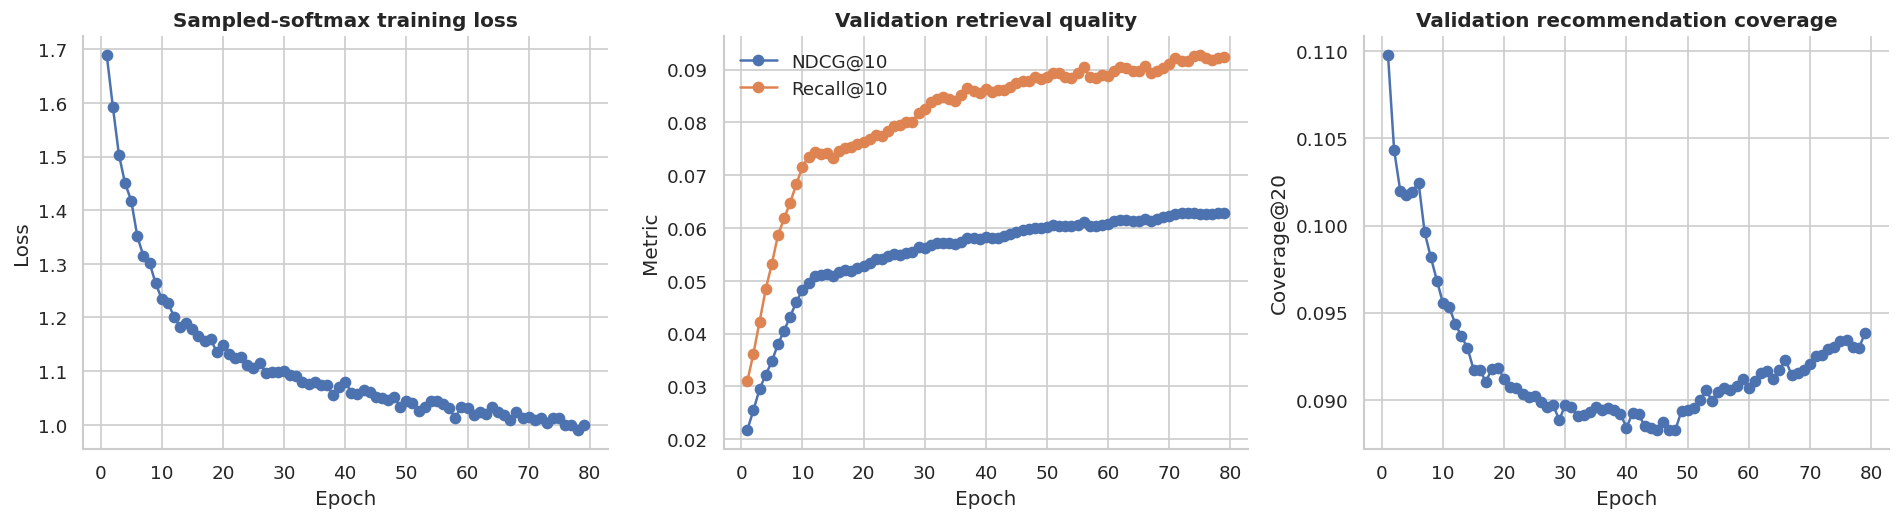

In [16]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history_df["epoch"], history_df["loss"], marker="o")
axes[0].set(
    title="Sampled-softmax training loss",
    xlabel="Epoch",
    ylabel="Loss",
)

eval_hist = history_df.dropna(subset=["val_NDCG@10"])

axes[1].plot(
    eval_hist["epoch"],
    eval_hist["val_NDCG@10"],
    marker="o",
    label="NDCG@10",
)
axes[1].plot(
    eval_hist["epoch"],
    eval_hist["val_Recall@10"],
    marker="o",
    label="Recall@10",
)
axes[1].set(
    title="Validation retrieval quality",
    xlabel="Epoch",
    ylabel="Metric",
)
axes[1].legend(frameon=False)

axes[2].plot(
    eval_hist["epoch"],
    eval_hist["val_Coverage@20"],
    marker="o",
)
axes[2].set(
    title="Validation recommendation coverage",
    xlabel="Epoch",
    ylabel="Coverage@20",
)

plt.show()

### GNN internals audit — after fitting

These diagnostics make the model's main engineering choices inspectable instead of leaving them implicit.

In [17]:
with torch.no_grad():
    layer_weights = torch.softmax(model.layer_logits, dim=0).cpu().numpy()
    initial_z = model.initial_state().cpu().numpy()
    final_z = model.encode().cpu().numpy()

component_norms = pd.DataFrame({
    "component": ["product embedding", "aisle embedding", "department embedding", "frequency projection"],
    "mean L2 norm": [
        float(model.base_embedding.weight.norm(dim=1).mean().detach().cpu()),
        float(model.aisle_embedding.weight.norm(dim=1).mean().detach().cpu()),
        float(model.dept_embedding.weight.norm(dim=1).mean().detach().cpu()),
        float(model.freq_projection(model.log_support_buf).norm(dim=1).mean().detach().cpu()),
    ],
})

graph_weight_stats = pd.DataFrame({
    "stat": ["min", "p50", "p95", "p99", "max", "mean"],
    "normalized edge weight": [
        float(np.min(edge_weight_cpu.numpy())),
        float(np.quantile(edge_weight_cpu.numpy(), 0.50)),
        float(np.quantile(edge_weight_cpu.numpy(), 0.95)),
        float(np.quantile(edge_weight_cpu.numpy(), 0.99)),
        float(np.max(edge_weight_cpu.numpy())),
        float(np.mean(edge_weight_cpu.numpy())),
    ],
})

negative_test_rng = np.random.default_rng(cfg.seed + 999)
neg_demo = sample_unique_negatives(
    context0,
    target0,
    min(cfg.negatives_per_positive, max(8, n_items - len(context0) - len(target0))),
    negative_test_rng,
)

print("Learned layer weights:", np.round(layer_weights, 4))
print("Initial-state / final-embedding mean cosine:",
      float(np.mean(np.sum(initial_z * final_z, axis=1))))

display(component_norms.style.format({"mean L2 norm": "{:.4f}"}).set_caption("Node-feature component contribution"))
display(graph_weight_stats.style.format({"normalized edge weight": "{:.6f}"}).set_caption("Normalized graph-edge weight distribution"))
print(
    f"Negative-sampling smoke test: {len(neg_demo)} unique negatives | "
    f"collisions={bool(set(map(int, neg_demo)) & (set(map(int, context0)) | set(map(int, target0))))}"
)

Learned layer weights: [0.5076 0.4924]
Initial-state / final-embedding mean cosine: 0.5172154307365417


,component,mean L2 norm
0,product embedding,0.4185
1,aisle embedding,0.2293
2,department embedding,0.2271
3,frequency projection,2.8574


,stat,normalized edge weight
0,min,0.000368
1,p50,0.026704
2,p95,0.046092
3,p99,0.069873
4,max,0.596308
5,mean,0.028135


Negative-sampling smoke test: 8 unique negatives | collisions=False


## 16. Validation benchmark: all models on the same basket questions

This table is the first neutral performance gate. Do not assume the GNN will dominate: if a classical model is stronger, that is an important result for a portfolio recommender system.

,model,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,Precision@20,Recall@20,NDCG@20,Coverage@20,Novelty@20
1,Item-kNN,0.0358,0.0707,0.0641,0.0259,0.0999,0.0752,0.0194,0.1469,0.0908,0.0243,0.1182
3,Graph-GNN,0.0302,0.0561,0.0487,0.0249,0.0925,0.0629,0.0188,0.1366,0.0777,0.0930,0.1452
0,Popularity,0.0291,0.0552,0.0486,0.0211,0.0778,0.0573,0.0152,0.1072,0.0676,0.0007,0.1133
2,Basket-MF,0.0078,0.0158,0.0125,0.0060,0.0251,0.0160,0.0046,0.0380,0.0201,0.2622,0.2771


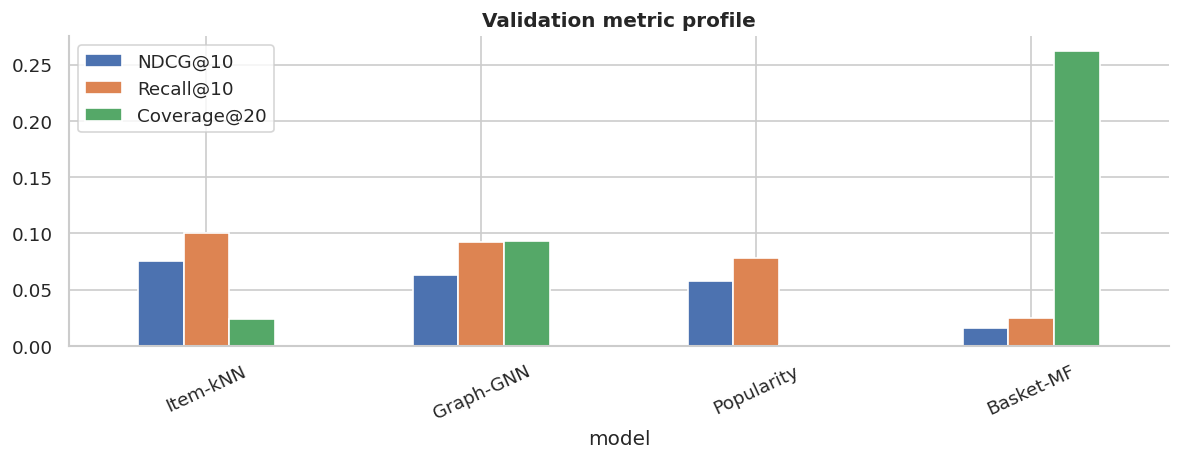

In [18]:
validation_models = [
    popularity,
    itemknn,
    basket_mf,
    model,
]

validation_rows = []
validation_per_query = {}

for candidate in validation_models:
    metrics, per_query_df, exposure = evaluate_model(
        candidate,
        val_examples,
        item_basket_support,
        ks=cfg.ks,
        batch_size=128,
        return_rows=True,
    )
    validation_rows.append({"model": candidate.name, **metrics})
    validation_per_query[candidate.name] = per_query_df

validation_results = pd.DataFrame(validation_rows).sort_values(
    "NDCG@10",
    ascending=False,
)

display(
    validation_results[
        [
            "model",
            "Precision@5", "Recall@5", "NDCG@5",
            "Precision@10", "Recall@10", "NDCG@10",
            "Precision@20", "Recall@20", "NDCG@20",
            "Coverage@20", "Novelty@20",
        ]
    ].style.format({
        c: "{:.4f}"
        for c in validation_results.columns
        if c != "model"
    }).set_caption("Validation-only benchmark")
)

# Additional model comparison visual
fig, ax = plt.subplots(figsize=(10, 4))
validation_results.plot.bar(x="model", y=["NDCG@10", "Recall@10", "Coverage@20"], ax=ax)
ax.set_title("Validation metric profile"); ax.tick_params(axis="x", rotation=25); plt.tight_layout(); plt.show()


## 17. Validation-tuned graph + kNN hybrid

Retail systems often combine a contextual neural signal with a strong co-occurrence prior.

The blend weight is tuned **only on validation NDCG@10**. We use robust percentile scaling rather than min-max scaling so one extreme score cannot flatten the rest of the catalog.

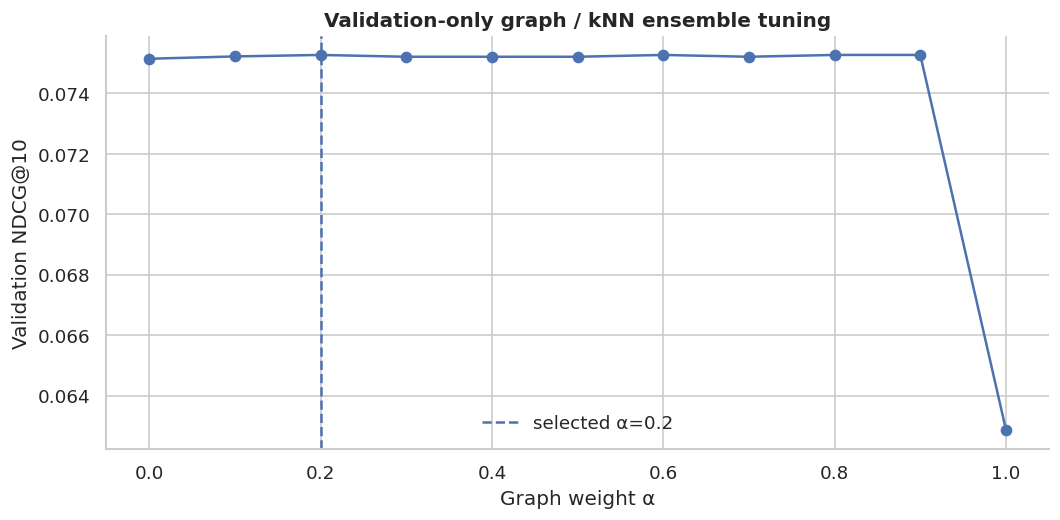

In [19]:
class HybridRecommender:
    name = "Graph + kNN"

    def __init__(self, graph_model, knn_model, alpha: float):
        self.graph_model = graph_model
        self.knn_model = knn_model
        self.alpha = float(alpha)

    def prepare_eval(self) -> None:
        if hasattr(self.graph_model, "_eval_z") and self.graph_model._eval_z is not None:
            return
        if hasattr(self.graph_model, "prepare_eval"):
            self.graph_model.prepare_eval()

    def score(self, contexts: list[np.ndarray]) -> np.ndarray:
        graph_scores = self.graph_model.score(contexts)
        knn_scores = self.knn_model.score(contexts)
        return (
            self.alpha * robust_row_scale(graph_scores)
            + (1.0 - self.alpha) * robust_row_scale(knn_scores)
        )


alpha_grid = np.linspace(0.0, 1.0, 11)
tuning_rows = []

for alpha in alpha_grid:
    candidate = HybridRecommender(model, itemknn, alpha=float(alpha))
    metrics = evaluate_model(
        candidate,
        val_examples,
        item_basket_support,
        ks=(10,),
        batch_size=128,
        return_rows=False,
    )
    tuning_rows.append({
        "alpha_graph": alpha,
        **metrics,
    })

tuning_df = pd.DataFrame(tuning_rows)
best_alpha = float(
    tuning_df.loc[tuning_df["NDCG@10"].idxmax(), "alpha_graph"]
)

hybrid = HybridRecommender(model, itemknn, alpha=best_alpha)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    tuning_df["alpha_graph"],
    tuning_df["NDCG@10"],
    marker="o",
)
ax.axvline(
    best_alpha,
    linestyle="--",
    linewidth=1.5,
    label=f"selected α={best_alpha:.1f}",
)
ax.set(
    title="Validation-only graph / kNN ensemble tuning",
    xlabel="Graph weight α",
    ylabel="Validation NDCG@10",
)
ax.legend(frameon=False)
plt.show()

## 18. Final test comparison + paired uncertainty

The test set is now evaluated once. Confidence intervals are basket-level bootstrap intervals; paired deltas reuse the exact same baskets to reduce noise when comparing models.

In [20]:
def bootstrap_mean_ci(
    values: np.ndarray,
    n_boot: int = 500,
    seed: int = 42,
) -> tuple[float, float, float]:
    x = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        means[i] = rng.choice(x, size=len(x), replace=True).mean()
    return float(x.mean()), float(np.quantile(means, 0.025)), float(np.quantile(means, 0.975))


test_models = [
    popularity,
    itemknn,
    basket_mf,
    model,
    hybrid,
]

test_rows = []
test_per_query = {}
test_exposure = {}

for candidate in test_models:
    metrics, per_query_df, exposure = evaluate_model(
        candidate,
        test_examples,
        item_basket_support,
        ks=cfg.ks,
        batch_size=128,
        return_rows=True,
    )

    mean, lo, hi = bootstrap_mean_ci(
        per_query_df["NDCG@10"].to_numpy(),
        n_boot=cfg.bootstrap_samples,
        seed=cfg.seed,
    )

    test_rows.append({
        "model": candidate.name,
        **metrics,
        "NDCG@10 CI": f"[{lo:.4f}, {hi:.4f}]",
    })

    test_per_query[candidate.name] = per_query_df
    test_exposure[candidate.name] = exposure

test_results = pd.DataFrame(test_rows)

knn_ndcg = float(
    test_results.loc[
        test_results["model"] == "Item-kNN",
        "NDCG@10",
    ].iloc[0]
)

test_results["NDCG@10 vs kNN"] = (
    test_results["NDCG@10"] / max(knn_ndcg, 1e-12) - 1.0
)

cols = [
    "model",
    "Precision@5", "Recall@5", "NDCG@5",
    "Precision@10", "Recall@10", "NDCG@10",
    "Precision@20", "Recall@20", "NDCG@20",
    "MRR@10", "Coverage@20", "Novelty@20",
    "NDCG@10 CI", "NDCG@10 vs kNN",
]

display(
    test_results[cols].style.format({
        c: "{:.4f}"
        for c in cols
        if c not in {"model", "NDCG@10 CI"}
    }).set_caption("Untouched test-set comparison")
)

,model,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,Precision@20,Recall@20,NDCG@20,MRR@10,Coverage@20,Novelty@20,NDCG@10 CI,NDCG@10 vs kNN
0,Popularity,0.0302,0.0552,0.0491,0.0214,0.0780,0.0577,0.0151,0.1102,0.0684,0.0857,0.0008,0.1133,"[0.0532, 0.0620]",-0.2533
1,Item-kNN,0.0366,0.0714,0.0650,0.0265,0.1039,0.0772,0.0191,0.1479,0.0916,0.1127,0.0307,0.1182,"[0.0725, 0.0824]",0.0000
2,Basket-MF,0.0054,0.0106,0.0084,0.0047,0.0196,0.0118,0.0042,0.0336,0.0164,0.0152,0.3288,0.2762,"[0.0099, 0.0139]",-0.8467
3,Graph-GNN,0.0289,0.0533,0.0471,0.0228,0.0848,0.0593,0.0170,0.1257,0.0729,0.0830,0.1111,0.1431,"[0.0554, 0.0635]",-0.2326
4,Graph + kNN,0.0366,0.0717,0.0651,0.0265,0.1035,0.0770,0.0190,0.1478,0.0915,0.1126,0.0303,0.1179,"[0.0723, 0.0822]",-0.0022


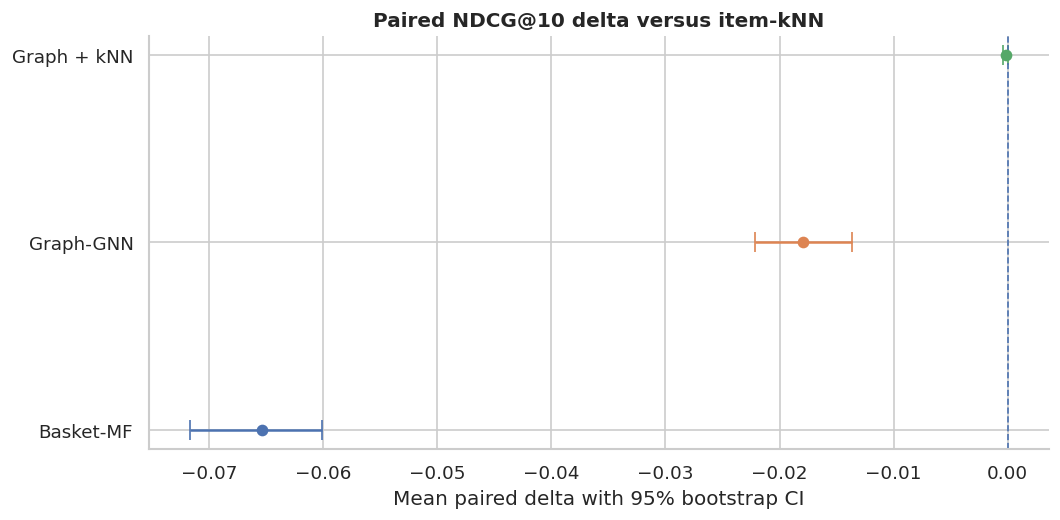

In [21]:
def paired_delta_ci(
    a: np.ndarray,
    b: np.ndarray,
    n_boot: int = 500,
    seed: int = 42,
) -> tuple[float, float, float]:
    diff = np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot, dtype=np.float64)

    for i in range(n_boot):
        means[i] = rng.choice(
            diff,
            size=len(diff),
            replace=True,
        ).mean()

    return (
        float(diff.mean()),
        float(np.quantile(means, 0.025)),
        float(np.quantile(means, 0.975)),
    )


delta_rows = []
knn_rows = test_per_query["Item-kNN"]["NDCG@10"].to_numpy()

for name in ["Basket-MF", "Graph-GNN", "Graph + kNN"]:
    mean, lo, hi = paired_delta_ci(
        test_per_query[name]["NDCG@10"].to_numpy(),
        knn_rows,
        n_boot=cfg.bootstrap_samples,
        seed=cfg.seed,
    )
    delta_rows.append({
        "model": name,
        "delta_vs_knn": mean,
        "lo": lo,
        "hi": hi,
    })

delta_df = pd.DataFrame(delta_rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, row in delta_df.reset_index(drop=True).iterrows():
    ax.errorbar(
        row["delta_vs_knn"],
        i,
        xerr=[[row["delta_vs_knn"] - row["lo"]],
              [row["hi"] - row["delta_vs_knn"]]],
        fmt="o",
        capsize=6,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(range(len(delta_df)))
ax.set_yticklabels(delta_df["model"])
ax.set(
    title="Paired NDCG@10 delta versus item-kNN",
    xlabel="Mean paired delta with 95% bootstrap CI",
)
plt.show()

## 19. Recommendation quality by visible-context size

A good enterprise analysis does not treat every basket equally. Context length changes the information available to the recommender, so we slice NDCG and Recall by visible basket size.

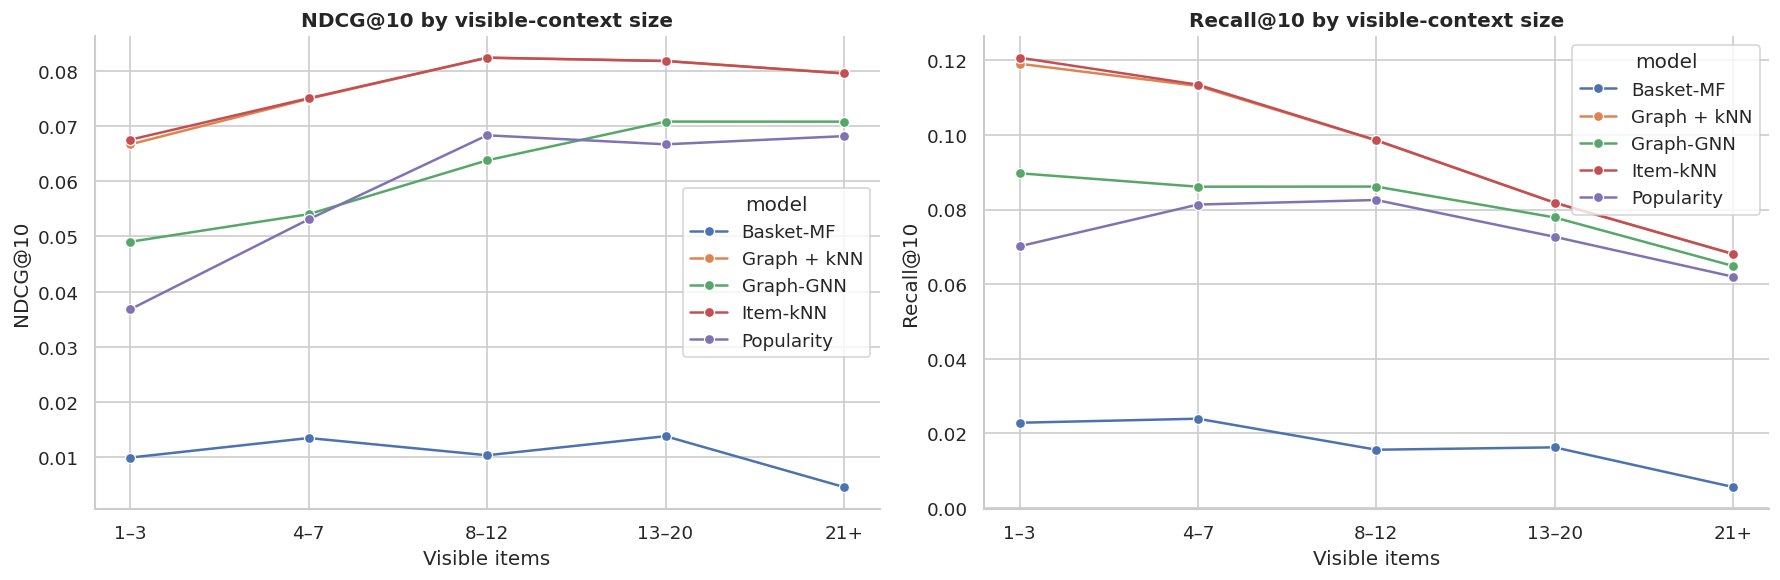

In [22]:
bands = [0, 3, 7, 12, 20, np.inf]
labels = ["1–3", "4–7", "8–12", "13–20", "21+"]

slice_frames = []
for name, rows in test_per_query.items():
    frame = rows.copy()
    frame["model"] = name
    frame["context band"] = pd.cut(
        frame["context_size"],
        bins=bands,
        labels=labels,
        include_lowest=True,
    )
    slice_frames.append(frame)

slices = pd.concat(slice_frames, ignore_index=True)

slice_ndcg = (
    slices.groupby(["context band", "model"], observed=True)["NDCG@10"]
    .mean()
    .reset_index()
)

slice_recall = (
    slices.groupby(["context band", "model"], observed=True)["Recall@10"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=slice_ndcg,
    x="context band",
    y="NDCG@10",
    hue="model",
    marker="o",
    ax=axes[0],
)
axes[0].set(
    title="NDCG@10 by visible-context size",
    xlabel="Visible items",
    ylabel="NDCG@10",
)

sns.lineplot(
    data=slice_recall,
    x="context band",
    y="Recall@10",
    hue="model",
    marker="o",
    ax=axes[1],
)
axes[1].set(
    title="Recall@10 by visible-context size",
    xlabel="Visible items",
    ylabel="Recall@10",
)

plt.show()

## 20. Popularity concentration and exposure diagnostics

Accuracy alone can hide a recommender that mostly repeats global best sellers.

This section compares recommendation exposure across popularity deciles. A healthy contextual model may still recommend popular items frequently — the issue is whether the catalog collapses toward a small head segment.

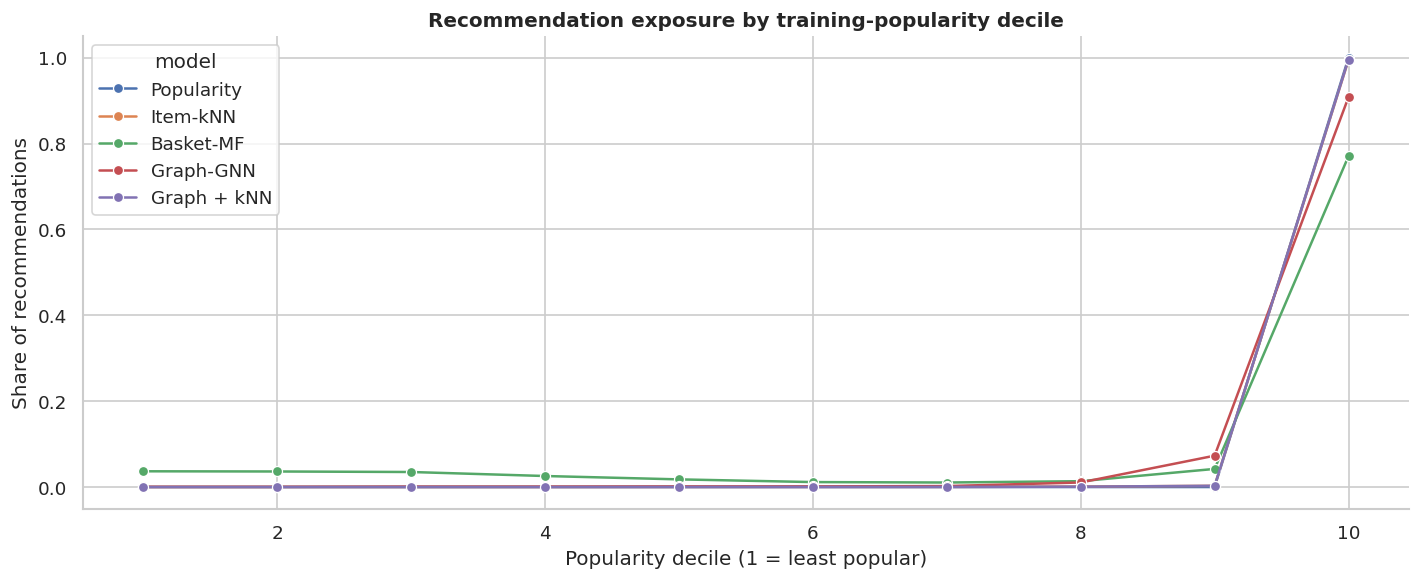

In [23]:
ranks = np.empty(len(item_basket_support), dtype=int)
ranks[np.argsort(item_basket_support)] = np.arange(len(item_basket_support))
decile = np.minimum(
    9,
    (10 * ranks / max(len(ranks), 1)).astype(int),
)

exposure_rows = []

for name, exposure in test_exposure.items():
    for d in range(10):
        share = exposure[decile == d].sum() / max(exposure.sum(), 1)
        exposure_rows.append({
            "model": name,
            "popularity decile": d + 1,
            "exposure share": share,
        })

exposure_df = pd.DataFrame(exposure_rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=exposure_df,
    x="popularity decile",
    y="exposure share",
    hue="model",
    marker="o",
    ax=ax,
)
ax.set(
    title="Recommendation exposure by training-popularity decile",
    xlabel="Popularity decile (1 = least popular)",
    ylabel="Share of recommendations",
)
plt.show()

## 21. Static graph embedding landscape

The strongest static representation combines the learned graph embeddings with a local structural plot.

A t-SNE projection is shown for the most frequently observed products. Point size encodes training support, while color encodes department. This is a visual diagnostic only; it is not treated as a performance metric.

We intentionally avoid interactive 3D libraries so the notebook remains portable to Kaggle's static notebook renderer.

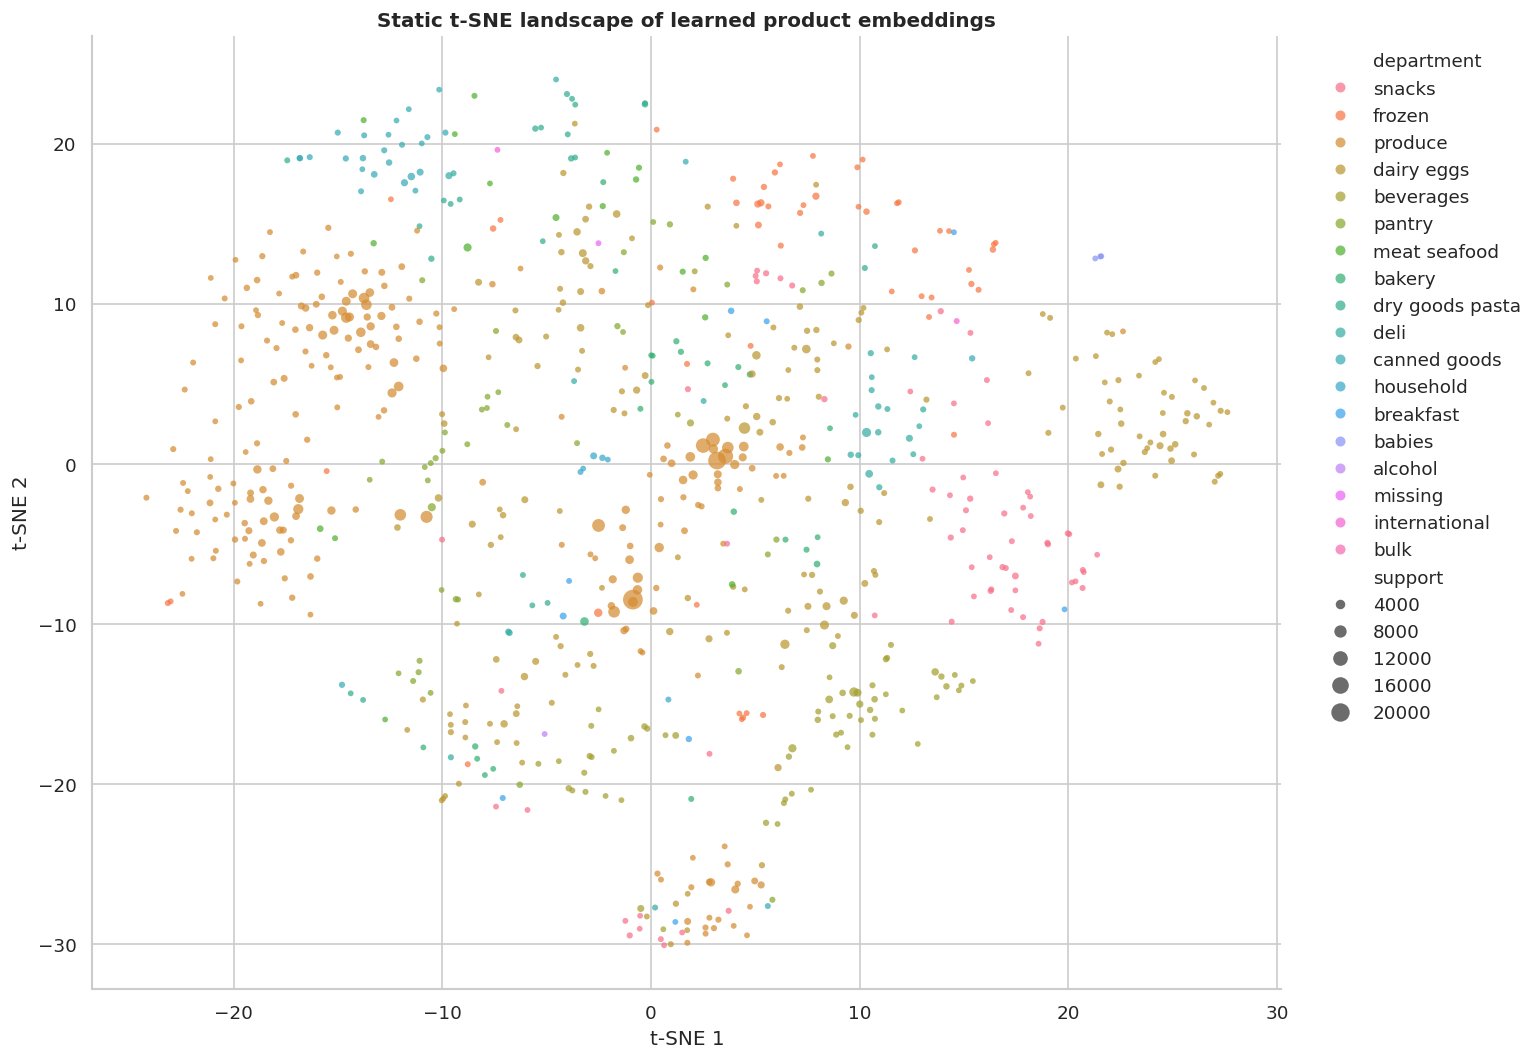

In [24]:
model.eval()
with torch.no_grad():
    Z = model.encode().cpu().numpy()

n_show = min(cfg.embedding_plot_nodes, n_items)
show_ids = np.argsort(item_basket_support)[-n_show:]

# PCA first reduces t-SNE workload while preserving a stable starting representation.
pca_dim = min(32, Z.shape[1], len(show_ids) - 1)
Z_pca = PCA(
    n_components=max(2, pca_dim),
    random_state=cfg.seed,
).fit_transform(Z[show_ids])

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=min(30, max(5, (len(show_ids) - 1) // 4)),
    random_state=cfg.seed,
)

coords = tsne.fit_transform(Z_pca)

embed_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "product": catalog_names[show_ids],
    "department": np.asarray(
        catalog["department"].fill_null("Unknown").to_list(),
        dtype=object,
    )[show_ids],
    "support": item_basket_support[show_ids],
})

fig, ax = plt.subplots(figsize=(13, 9))
sns.scatterplot(
    data=embed_df,
    x="x",
    y="y",
    hue="department",
    size="support",
    sizes=(12, 140),
    alpha=0.72,
    linewidth=0,
    ax=ax,
)
ax.set_title("Static t-SNE landscape of learned product embeddings")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)
plt.show()

## 22. Recommendation inspection and local explanations

For a few deterministic test baskets, inspect:
- visible context
- hidden target products
- top recommendations from kNN, GNN, and hybrid
- whether the hidden target was recovered
- the closest visible product in the learned graph space

The closest-visible-product field is a **local similarity explanation**, not a causal explanation.

In [25]:
def top_k_items(candidate, context: np.ndarray, k: int = 10):
    scores = candidate.score([context])[0].copy()
    scores[context] = -np.inf

    top = np.argpartition(-scores, k - 1)[:k]
    top_scores = scores[top]
    order = np.argsort(-top_scores)
    top = top[order]

    return top, scores


def inspect_basket(
    example: tuple[np.ndarray, np.ndarray],
    k: int = 10,
):
    context, truth = example

    rec_knn, _ = top_k_items(itemknn, context, k)
    rec_gnn, _ = top_k_items(model, context, k)
    rec_hyb, _ = top_k_items(hybrid, context, k)

    truth_set = set(map(int, truth))
    reasons = []

    for item in rec_hyb:
        similarity = Z[context] @ Z[item]
        reasons.append(
            catalog_names[context[int(np.argmax(similarity))]]
        )

    table = pd.DataFrame({
        "rank": np.arange(1, k + 1),
        "hybrid recommendation": catalog_names[rec_hyb],
        "hybrid hit": [int(x in truth_set) for x in rec_hyb],
        "closest visible product": reasons,
        "kNN": catalog_names[rec_knn],
        "GNN": catalog_names[rec_gnn],
    })

    return (
        table,
        catalog_names[context].tolist(),
        catalog_names[truth].tolist(),
    )


# Deterministic examples: one successful case, one failure case, one large-context case.
hybrid_rows = test_per_query["Graph + kNN"]

hit_ids = np.flatnonzero(
    hybrid_rows["NDCG@10"].to_numpy() > 0
)
miss_ids = np.flatnonzero(
    hybrid_rows["NDCG@10"].to_numpy() == 0
)

context_sizes = np.asarray([len(x[0]) for x in test_examples])
large_id = int(np.argmax(context_sizes))

selected_ids = []
if len(hit_ids):
    selected_ids.append(int(hit_ids[0]))
if len(miss_ids):
    selected_ids.append(int(miss_ids[0]))
selected_ids.append(large_id)

# De-duplicate while preserving order.
selected_ids = list(dict.fromkeys(selected_ids))

for example_id in selected_ids[:3]:
    table, visible, hidden = inspect_basket(
        test_examples[example_id],
        k=10,
    )
    print(f"Test example {example_id}")
    print("Visible:", visible)
    print("Hidden:", hidden)
    display(table)

Test example 1
Visible: ['Creamy Peanut Butter', 'Roasted Red Pepper Hummus', 'Pita Chips Simply Naked', 'GOLEAN Crunch! Cereal', 'Go Lean Cereal', "Crunchy Oats N' Honey Granola Bars", 'Ground Coffee Dark Roast', 'Sierra Trail Mix Energy Bar']
Hidden: ['Banana', 'Half & Half']


,rank,hybrid recommendation,hybrid hit,closest visible product,kNN,GNN
0,1,Banana,1,Roasted Red Pepper Hummus,Banana,Banana
1,2,Bag of Organic Bananas,0,Roasted Red Pepper Hummus,Bag of Organic Bananas,Honey Nut Cheerios
2,3,Organic Strawberries,0,Roasted Red Pepper Hummus,Organic Strawberries,100% Whole Wheat Bread
3,4,Organic Avocado,0,Roasted Red Pepper Hummus,Organic Avocado,Strawberries
4,5,Large Lemon,0,Roasted Red Pepper Hummus,Large Lemon,Organic Fuji Apple
5,6,Organic Hass Avocado,0,Roasted Red Pepper Hummus,Organic Hass Avocado,Organic Half & Half
6,7,Organic Baby Spinach,0,Roasted Red Pepper Hummus,Organic Baby Spinach,Large Lemon
7,8,Strawberries,0,Creamy Peanut Butter,Strawberries,Organic Avocado
8,9,Limes,0,Roasted Red Pepper Hummus,Limes,Whole Milk
9,10,Organic Raspberries,0,Roasted Red Pepper Hummus,Organic Raspberries,Organic 2% Reduced Fat Milk


Test example 0
Visible: ['Marinara Pasta Sauce', 'Boneless Skinless Chicken Thighs', 'Cage Free Large White Eggs']
Hidden: ['Unsweetened Original Almond Breeze Almond Milk']


,rank,hybrid recommendation,hybrid hit,closest visible product,kNN,GNN
0,1,Banana,0,Boneless Skinless Chicken Thighs,Banana,Grated Parmesan
1,2,Organic Baby Spinach,0,Marinara Pasta Sauce,Organic Baby Spinach,Artichoke Spinach Dip
2,3,Organic Strawberries,0,Marinara Pasta Sauce,Organic Strawberries,Organic Yellow Onion
3,4,Bag of Organic Bananas,0,Marinara Pasta Sauce,Bag of Organic Bananas,Boneless Skinless Chicken Breasts
4,5,Organic Avocado,0,Boneless Skinless Chicken Thighs,Organic Avocado,Organic Extra Firm Tofu
5,6,Organic Hass Avocado,0,Cage Free Large White Eggs,Organic Hass Avocado,Organic Avocado
6,7,Limes,0,Boneless Skinless Chicken Thighs,Limes,Organic Sour Cream
7,8,Large Lemon,0,Boneless Skinless Chicken Thighs,Large Lemon,Organic Red Onion
8,9,Organic Whole Milk,0,Cage Free Large White Eggs,Organic Whole Milk,Shredded Mozzarella
9,10,Cucumber Kirby,0,Boneless Skinless Chicken Thighs,Cucumber Kirby,Organic Cilantro


Test example 3702
Visible: ['Bag of Organic Bananas', 'Organic Hass Avocado', 'Apple Honeycrisp Organic', 'Fresh Cauliflower', 'Organic Peeled Whole Baby Carrots', 'Grated Parmesan', 'Sparkling Natural Mineral Water', 'Organic Navel Orange', '100% Raw Coconut Water', 'Romaine Hearts', 'Organic Bell Pepper', 'Uncured Hickory Smoked Sunday Bacon', 'Organic Large Green Asparagus', 'Globe Eggplant', 'Large Brown Eggs', 'Alpine Spring Water', 'Smartwater', 'Low Fat 1% Milk', 'Organic Greek Nonfat Yogurt With Mixed Berries', 'Organic Nonfat Greek Yogurt With Peaches', 'Organic Sprouted Wheat Bagels', 'Beet Apple Carrot Lemon Ginger Organic Cold Pressed Juice Beverage', 'Muffins, Flax, Wild Blueberry', 'Gluten-Free Supergrain Pasta Organic Corn & Quinoa Blend Penne', 'Greek Whole Milk Blended Blueberry Yogurt', 'Organic Blended Raspberry Whole Milk Greek Yogurt', 'Organic Extra Virgin Oil Olive', 'Organic Low Fat Plain Yogurt', 'Organic Gluten Free Sea Salt by the Seashore Multigrain Tortilla

,rank,hybrid recommendation,hybrid hit,closest visible product,kNN,GNN
0,1,Organic Strawberries,1,Bag of Organic Bananas,Organic Strawberries,Organic Strawberries
1,2,Organic Baby Spinach,0,Organic Hass Avocado,Organic Baby Spinach,Organic Raspberries
2,3,Banana,0,Bag of Organic Bananas,Banana,Organic Whole Milk
3,4,Organic Raspberries,0,Bag of Organic Bananas,Organic Raspberries,Organic Baby Spinach
4,5,Organic Yellow Onion,0,Fresh Cauliflower,Organic Yellow Onion,Organic Lemon
5,6,Limes,0,Bag of Organic Bananas,Limes,Organic Large Extra Fancy Fuji Apple
6,7,Organic Zucchini,0,Fresh Cauliflower,Organic Zucchini,Organic Avocado
7,8,Organic Garlic,0,Fresh Cauliflower,Organic Garlic,Organic Gala Apples
8,9,Organic Lemon,1,Organic Hass Avocado,Organic Lemon,Organic Whole String Cheese
9,10,Large Lemon,0,Bag of Organic Bananas,Large Lemon,Banana


## 23. Model card

### Scope
Anonymous within-basket completion over the Instacart `prior` orders.

### Strengths
- Training-only graph construction
- Polars lazy/streaming transaction pipeline
- Sparse-matrix graph construction rather than Python pair loops
- Full-candidate ranking over the retained model catalog
- Classical popularity, co-occurrence, and matrix-factorization baselines
- Explicit graph-weight normalization
- Metadata-aware product representations
- Collision-safe hard-negative training
- Frozen validation/test masks
- Paired bootstrap uncertainty
- Static graph and embedding diagnostics

### Limitations
- This is not personalized next-basket prediction.
- A training-only candidate catalog creates a genuine cold-start boundary; target recallability is reported rather than hidden.
- The anonymous dataset lacks price, margin, promotion, inventory, availability, and substitution context.
- Random order-level splitting does not measure future assortment drift.
- Hidden items are assumed equally relevant.
- t-SNE visual structure is diagnostic, not proof of semantic quality.

### Suggested next production experiments
- chronological leave-last-order-out user split
- user/product time features
- margin-aware ranking objective
- availability-aware candidate generation
- category diversity constraints
- calibrated probability estimates
- online A/B test with guardrails
- model monitoring for catalog drift and popularity concentration